# Satellite Compact Dwarf Galaxies in TNG50 (Paper I) — Reproducible Figure Notebook

This notebook reproduces the **satellite**-focused figures and statistical checks used in *Paper I* (TNG50), following the same professional structure as the `CentralCompact...` notebook.

## What this notebook contains
- A single **configuration & data-loading** block (cosmology, paths, key dataframes)
- One section per **figure** (Fig. 1–23), keeping the original plotting calls unchanged
- A small **diagnostics** section at the end (optional)


## Notebook map

- **0. Imports**
- **1. Configuration & data loading**
- **2. Figure reproduction sections (Fig. 1–23)**
- **3. Optional diagnostics**


## 0. Imports
This cell loads the scientific Python stack and your local analysis modules.

In [1]:
# --- Imports (scientific Python + local project modules) ---
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.append(os.getenv("HOME")+"/PROJECTS/2026/DwarfGalaxies_TNG50_FAPESP/analyzes")
sys.path.append(os.getenv("HOME")+"/PROJECTS/2026/DwarfGalaxies_TNG50_FAPESP/src")
sys.path.append(os.getenv("HOME")+"/PROJECTS/2026/DwarfGalaxies_TNG50_FAPESP/analyzes/GaryScripts")

import TNGFunctions as TNG
import ExtractTNG as ETNG

import PlotFunctions as plot
import MATH

try:
    plt.style.use("abhner.mplstyle")
except OSError:
    warnings.warn("Custom matplotlib style 'abhner.mplstyle' not found. Using default style.")
    
warnings.filterwarnings("ignore")


## 1. Configuration & data loading

This section defines:
- cosmological parameters (for labels/conversions)
- simulation identifier (`SIMTNG`)
- paths to common tables (e.g. `SNAPS_TIME.csv`)
- the key dataframes used across multiple figures


In [2]:
# --- Cosmological parameters (consistent with IllustrisTNG metadata) ---
Omegam0 = 0.3089
h = 0.6774

# --- Simulation tag used by your I/O helpers ---
SIMTNG = "TNG50"

# --- Base paths ---
HOME = Path(os.getenv("HOME", "."))
SUBHALO_HISTORY_PATH = HOME / "TNG_Analyzes" / "SubhaloHistory"

# --- Common tables ---
SNAPS_TIME_PATH = SUBHALO_HISTORY_PATH / "SNAPS_TIME.csv"
dfTime = pd.read_csv(SNAPS_TIME_PATH)

# --- Main data products (exported from your pipeline) ---
df_z0_Mstar_Range = TNG.extractDF("Sample", SIM=SIMTNG)
PaperII = TNG.extractDF("PaperII", SIM=SIMTNG)

# Quick sanity checks (optional)
display(dfTime.head(3))
display(df_z0_Mstar_Range.head(3))


,Unnamed: 0,Snap,z,Age,LBTime
0,0,99,0.000000,13.802819,0.000000
1,1,98,0.009522,13.666329,0.136490
2,2,97,0.023974,13.462742,0.340077


,SubfindID_99,logMstarRad_99,logHalfRadstar_99,Flags,GMMIndex,Name,CentralSatellite,SnapBorn,StatusBorn,ProgenitorStatus,...,GasConrotateFrac_after_2Gyr_Birth,GasConrotateFrac_after_5Gyr_Birth,GasConrotateFrac_after_8Gyr_Birth,GasFracCorotate_at_Birth,meanGasFracCorotate_at_Birth,meanGasFracCorotate_after_05Gyr_Birth,meanGasFracCorotate_after_1Gyr_Birth,meanGasFracCorotate_after_2Gyr_Birth,meanGasFracCorotate_after_5Gyr_Birth,meanGasFracCorotate_after_8Gyr_Birth
0,45,9.092222,0.514900,1.0,0,Normal,Satellite,2.0,BornOld,WithProgenitor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,48,9.149221,0.385765,1.0,0,Normal,Satellite,1.0,BornOld,WithProgenitor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,53,9.037461,0.581932,1.0,0,SubDiffuse,Satellite,1.0,BornOld,WithProgenitor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Figure 1

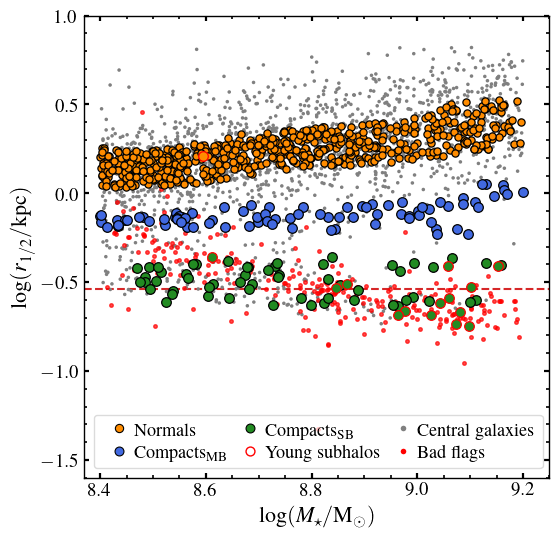

In [3]:
fig=plt.figure(facecolor='white')
plt.rcParams.update({'figure.figsize': (6, 4.5)})
X = np.transpose(np.array([df_z0_Mstar_Range.loc[df_z0_Mstar_Range.CentralSatellite == 'Central', 'logMstarRad_99'].values,
                           df_z0_Mstar_Range.loc[df_z0_Mstar_Range.CentralSatellite == 'Central', 'logHalfRadstar_99'].values]))
Masses = np.linspace(8.4, 9.2, 100)



#plt.axhspan(-2.2, np.log10(0.6), facecolor='tab:red', alpha=0.25)

plt.scatter(X[:,0],X[:,1],s=6.5,c='gray',ec='none')

# Main branch

# Normals

plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('BadFlag', SubfindID_99 = True))],
            PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('BadFlag', SubfindID_99 = True))],
            s=6.5,c='red', ec = 'red', alpha = 0.7)


plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('NormalSatellite', SubfindID_99 = True))],
            PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('NormalSatellite', SubfindID_99 = True))],
            s=4.5*6,c='darkorange', linewidths= 0.9)

plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('NormalBornYoungSatellite', SubfindID_99 = True))],
             PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('NormalBornYoungSatellite', SubfindID_99 = True))],
             s=8*6,c='darkorange', ec = 'red', linewidths= .9)

plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('MBCSatellite', SubfindID_99 = True))],
            PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('MBCSatellite', SubfindID_99 = True))],
            s=8*6,c='royalblue',  linewidths= .9)

plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('MBCBornYoungSatellite', SubfindID_99 = True))],
             PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('MBCBornYoungSatellite', SubfindID_99 = True))],
             s=8*6,c='royalblue', ec = 'red', linewidths= .9)

plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('SBCSatellite', SubfindID_99 = True))],
            PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('SBCSatellite', SubfindID_99 = True))],
            s=8*6,c='forestgreen',  linewidths= .9)

plt.scatter(PaperII.logMstarRad_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('SBCBornYoungSatellite', SubfindID_99 = True))],
             PaperII.logHalfRadstar_99[PaperII.SubfindID_99.isin(TNG.extractPopulation('SBCBornYoungSatellite', SubfindID_99 = True))],
             s=8*6,c='forestgreen', ec = 'red',  linewidths= .9)



#plt.axhline(np.log10(0.6), color = 'red', ls = '-', lw = 1.1)

columnspacing = 0.2
handletextpad = -0.2
labelspacing = 0.3
fontlegend= 22
framealpha= 0.7
alphaScater=0.8
quantile=0.28

custom_lines, label, ncol, mult = plot.Legend(
    ['NormalBlackLineScatter',  'MBCBlackLineScatter', 'SBCBlackLineScatter', 'BornYoungSystemsEmptyScatter', 'TNGrageCentralScatter','BadFlagScatter'])
plt.legend(
    custom_lines, label, ncol=3, fontsize=mult*fontlegend, framealpha=framealpha, 
    columnspacing = columnspacing, handletextpad = handletextpad, labelspacing = labelspacing)

rSoftening =  0.28786537
#plt.fill_between(np.linspace(8.2, 9.8), -2., np.log10(rSoftening), alpha=0.1, color="tab:red")
plt.axhline(np.log10(rSoftening), alpha=1.0,  lw= 1.5, ls = 'dashed', color="tab:red", zorder = 0)

plt.ylim(-1.6, 1.0)
plt.xlim(8.37, 9.25)
plt.tick_params(labelsize = 0.85 * 16)
plt.xlabel(r'$\log(M_\star/\mathrm{M}_\odot)$', fontsize = 16)
plt.ylabel(r'$\log(r_{1/2}/\mathrm{kpc})$', fontsize = 16)


plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/' + SIMTNG + '/PaperII/PlotScatter/sizevsM_Classes.pdf')

## Figure 2

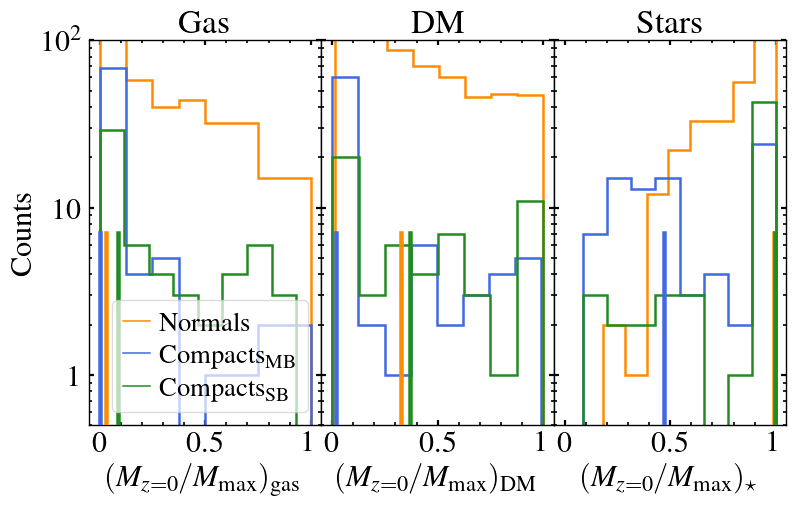

In [4]:
plot.PlotHist(['Normal',  'MBC', 'SBC'], 
              ['Mgas_Norm_Max_99',
             'MDM_Norm_Max_99', 'Mstar_Norm_Max_99'], ['Satellite'],  Type = 'z0',
               savepath='PaperII/PlotHist',  savefigname='Gas', dfName='PaperII', SampleName='SubfindID_99', 
                density=False, 
                ColumnPlot = False, bins=[[8, 8, 8]], median=True,  legend = True, 
                lNum = 5, cNum = 3, GridMake = False,
                LegendNames = [[ 'Normal', 'MBC', 'SBC']], 
                xlimmin = [-0.05, -0.05, -0.05], xlimmax = [1.05, 1.05, 1.05],  
                legpositions = [[0, 0]], title = ['Gas', 'DM', 'Stars'],
                yscale = 'log',loc=['best'],TRANSPARENT = True, LookBackTime = True,
                fontlabel=22,  handlelength = 1,
                framealpha=0.7, handletextpad = 0.35)

## Figure 3

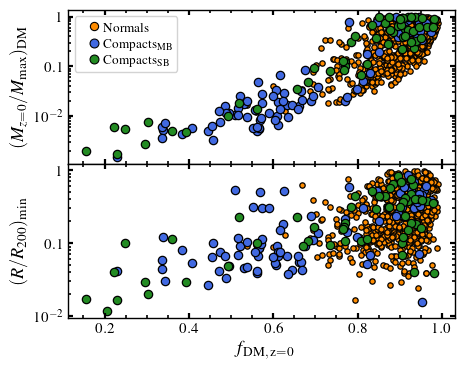

In [5]:
plot.PlotScatter(['Normal','MBC', 'SBC'], ['Satellite'], 'DMFrac_99', ['MDM_Norm_Max_99', 'rOverR200Min'],  Type='z0', snap=[99],
 title=False, medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalBlackLineScatter', 'MBCBlackLineScatter', 'SBCBlackLineScatter']],  TRANSPARENT = False, COLORBAR = None, medianDot = False, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=11,  
                m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 2, cNum = 5, GridMake = False,
                #ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [6e-3], xlimmax = [25],  
                legpositions = [[0, 0]],  
                columnspacing = 0.5, handletextpad = -0.3, labelspacing = 0.3, loc = ['best'],
                savepath='PaperII/PlotScatter',  savefigname='DMFracMaxTot', dfName='PaperII', SampleName='Samples', cmap = 'inferno',
                bins=10, seed=16010504, mult = 4.1)

In [6]:
import numpy as np
from scipy.stats import fisher_exact

# Exemplo:
# a = pre-processed among DM-poor
# b = not pre-processed among DM-poor
# c = pre-processed among comparison sample
# d = not pre-processed among comparison sample

a = len(TNG.extractPopulation('MBCSatelliteDMpoorPreProcessingGalaxy', dfName = 'PaperII'))
b = len(TNG.extractPopulation('MBCSatelliteDMpoorNotProcessing', dfName = 'PaperII'))
c = len(TNG.extractPopulation('MBCSatelliteDMrichPreProcessingGalaxy', dfName = 'PaperII'))
d = len(TNG.extractPopulation('MBCSatelliteDMrichNotProcessing', dfName = 'PaperII'))

table = np.array([[a, b],
                  [c, d]])

oddsratio, pvalue = fisher_exact(table, alternative='greater')

print("Odds ratio =", oddsratio)
print("p-value =", pvalue)
import numpy as np
from scipy.stats import fisher_exact

# Exemplo:
# a = pre-processed among DM-poor
# b = not pre-processed among DM-poor
# c = pre-processed among comparison sample
# d = not pre-processed among comparison sample

a = len(TNG.extractPopulation('SBCSatelliteDMpoorPreProcessingGalaxy', dfName = 'PaperII'))
b = len(TNG.extractPopulation('SBCSatelliteDMpoorNotProcessing', dfName = 'PaperII'))
c = len(TNG.extractPopulation('SBCSatelliteDMrichPreProcessingGalaxy', dfName = 'PaperII'))
d = len(TNG.extractPopulation('SBCSatelliteDMrichNotProcessing', dfName = 'PaperII'))

table = np.array([[a, b],
                  [c, d]])

oddsratio, pvalue = fisher_exact(table, alternative='greater')

print("Odds ratio =", oddsratio)
print("p-value =", pvalue)

Odds ratio = 3.125
p-value = 0.04510791192525814
Odds ratio = 8.863636363636363
p-value = 0.014832594889841223


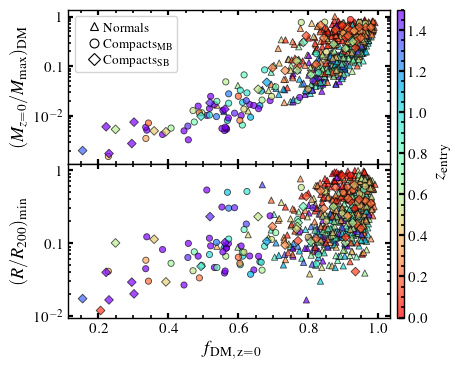

In [7]:
plot.PlotScatter(['Normal','MBC', 'SBC'], ['Satellite'], 'DMFrac_99', ['MDM_Norm_Max_99', 'rOverR200Min'],  Type='z0', snap=[99],
 title=False, medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalColorbarBlackLineScatter', 'MBCColorbarBlackLineScatter', 'SBCColorbarBlackLineScatter']],  TRANSPARENT = False, COLORBAR = ['z_At_FirstEntry', 'z_At_FirstEntry'], medianDot = False, 
                alphaScater=0.7,   alphaShade=0.3,  linewidth=0.2,
                fontlabel=11,  
                m='o', msizet=2.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 2, cNum = 5, GridMake = False,
                #ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [6e-3], xlimmax = [25],  
                legpositions = [[0, 0]],  
                columnspacing = 0.5, handletextpad = -0.3, labelspacing = 0.3, loc = ['best'],
                savepath='PaperII/PlotScatter',  savefigname='DMFracMaxTot', dfName='PaperII', SampleName='Samples', cmap = 'rainbow_r',
                bins=10, seed=16010504, mult = 4.1)

## Figure 4

IndexError: list index out of range

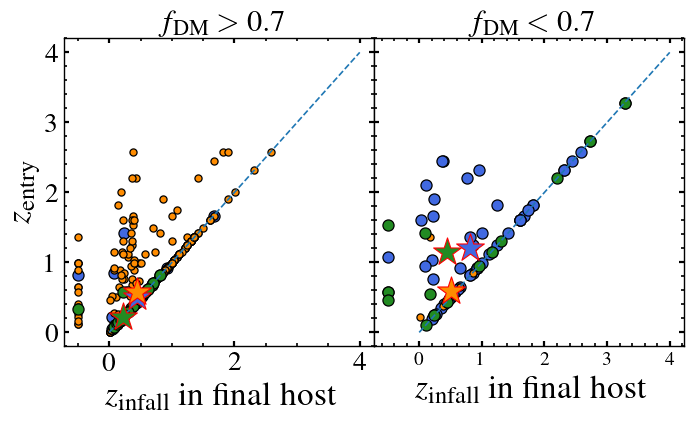

In [8]:
plot.PlotScatter([ 'MBC', 'Normal', 'SBC'], ['SatelliteDMrich', 'SatelliteDMpoor'], 'z_At_FinalEntry', 'z_At_FirstEntry',  Type='z0', snap=[99],
 title=['DMrich','DMpoor'],medianBins=False, medianAll=False, xlabelintext=False, All=None, 
                legend=True, LegendNames=[['NormalBlackLineScatter', 'MBCBlackLineScatter', 'SBCBlackLineScatter']],  TRANSPARENT = True,  medianDot = True, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=20,  msizeMult = 1.2,
                m='o', msizet=8, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 4, cNum = 4, GridMake = False,
                #ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [6e-3], xlimmax = [25],  
                legpositions = [[1, 0]],  
                columnspacing = 0.5, handletextpad = -0.2, labelspacing = 0.3, loc = ['best'], EqualLine = True, EqualLineMin = 0, EqualLineMax = 4,
                savepath='PaperII/PlotScatter',  savefigname='SnapEntry', dfName='PaperII', SampleName='Samples', cmap = 'Reds',
                bins=10, seed=16010504, mult = 6.1)

In [ ]:
TNG.compare_Sample_key('z_At_FinalEntry', [['Normal_Satellite_DMpoor', 'MBC_Satellite_DMpoor'],
                               ['SBC_Satellite_DMpoor', 'MBC_Satellite_DMpoor'],
                               ['Normal_Satellite_DMpoor', 'SBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('z_At_FirstEntry', [['Normal_Satellite_DMpoor', 'MBC_Satellite_DMpoor'],
                               ['SBC_Satellite_DMpoor', 'MBC_Satellite_DMpoor'],
                               ['Normal_Satellite_DMpoor', 'SBC_Satellite_DMpoor']], dfName = 'PaperII')

Normal_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  0.503 0.834
Observed Test Statistic: 0.33089
Permutation Test P-Value: 0.25626
SBC_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  1.053 0.834
Observed Test Statistic: 0.21848
Permutation Test P-Value: 0.42754
Normal_Satellite_DMpoor  and  SBC_Satellite_DMpoor
Medians:  0.503 1.053
Observed Test Statistic: 0.54937
Permutation Test P-Value: 0.23608


Normal_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  0.585 1.202
Observed Test Statistic: 0.61693
Permutation Test P-Value: 0.0851
SBC_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  1.155 1.202
Observed Test Statistic: 0.04693
Permutation Test P-Value: 0.98988
Normal_Satellite_DMpoor  and  SBC_Satellite_DMpoor
Medians:  0.585 1.155
Observed Test Statistic: 0.57
Permutation Test P-Value: 0.3214


In [ ]:
TNG.compare_Sample_key('z_At_FinalEntry', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor'],
                               ['SBC_Satellite_DMrich', 'SBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('z_At_FirstEntry', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor'],
                               ['SBC_Satellite_DMrich', 'SBC_Satellite_DMpoor']], dfName = 'PaperII')


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  0.461 0.503
Observed Test Statistic: 0.04228
Permutation Test P-Value: 0.80328
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  0.461 0.834
Observed Test Statistic: 0.37303
Permutation Test P-Value: 0.03074
SBC_Satellite_DMrich  and  SBC_Satellite_DMpoor
Medians:  0.214 1.053
Observed Test Statistic: 0.83814
Permutation Test P-Value: 4e-05


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  0.576 0.585
Observed Test Statistic: 0.00862
Permutation Test P-Value: 0.97236
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  0.503 1.202
Observed Test Statistic: 0.69849
Permutation Test P-Value: 0.00692
SBC_Satellite_DMrich  and  SBC_Satellite_DMpoor
Medians:  0.214 1.155
Observed Test Statistic: 0.94018
Permutation Test P-Value: 4e-05


## Figure 5

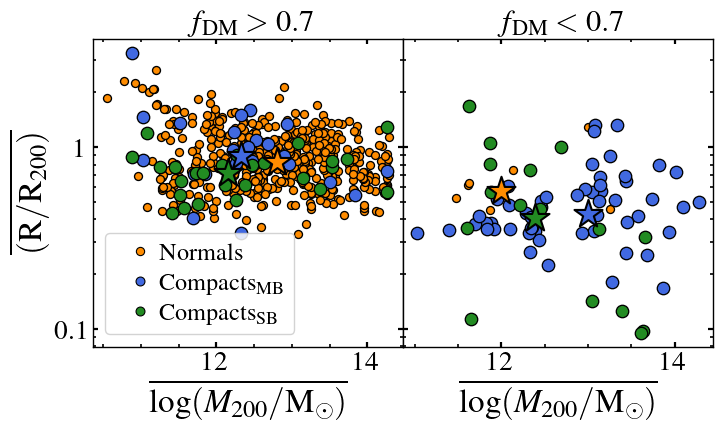

In [ ]:
plot.PlotScatter(['Normal','MBC', 'SBC'], ['SatelliteDMrich', 'SatelliteDMpoor'], 'M200Mean', ['rOverR200Mean_New'],  Type='z0', snap=[99],
 title=['DMrich','DMpoor'],medianBins=False, medianAll=False, xlabelintext=False, All=None, # COLORBAR = ['TimeInnerRegion'],
                legend=True, LegendNames=[['NormalBlackLineScatter', 'MBCBlackLineScatter', 'SBCBlackLineScatter']],  TRANSPARENT = True,  medianDot = True, 
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=20,  msizeMult = 1.2,
                m='o', msizet=10, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 4, cNum = 4, GridMake = False,
                #ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [6e-3], xlimmax = [25],  
                legpositions = [[0, 0]],  
                columnspacing = 0.5, handletextpad = -0.2, labelspacing = 0.3, loc = ['best'], EqualLine = False, EqualLineMin = 0, EqualLineMax = 4,
                savepath='PaperII/PlotScatter',  savefigname='Environment', dfName='PaperII', SampleName='Samples', cmap = 'rainbow',
                bins=10, seed=16010504, mult = 6.1)

In [ ]:
TNG.compare_Sample_key('M200Mean', [['Normal_Satellite_DMpoor', 'MBC_Satellite_DMpoor'],
                               ['SBC_Satellite_DMpoor', 'MBC_Satellite_DMpoor'],
                               ['Normal_Satellite_DMpoor', 'SBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('rOverR200Mean', [['Normal_Satellite_DMpoor', 'MBC_Satellite_DMpoor'],
                               ['SBC_Satellite_DMpoor', 'MBC_Satellite_DMpoor'],
                               ['Normal_Satellite_DMpoor', 'SBC_Satellite_DMpoor']], dfName = 'PaperII')

Normal_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  12.002 13.003
Observed Test Statistic: 1.00096
Permutation Test P-Value: 0.01584
SBC_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  12.39 13.003
Observed Test Statistic: 0.61346
Permutation Test P-Value: 0.17314
Normal_Satellite_DMpoor  and  SBC_Satellite_DMpoor
Medians:  12.002 12.39
Observed Test Statistic: 0.3875
Permutation Test P-Value: 0.46024


Normal_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  0.629 0.414
Observed Test Statistic: 0.21441
Permutation Test P-Value: 0.01146
SBC_Satellite_DMpoor  and  MBC_Satellite_DMpoor
Medians:  0.429 0.414
Observed Test Statistic: 0.01478
Permutation Test P-Value: 0.8592
Normal_Satellite_DMpoor  and  SBC_Satellite_DMpoor
Medians:  0.629 0.429
Observed Test Statistic: 0.19963
Permutation Test P-Value: 0.0736


In [ ]:
TNG.compare_Sample_key('M200Mean', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor'],
                               ['SBC_Satellite_DMrich', 'SBC_Satellite_DMpoor']], dfName = 'PaperII')
print('\n')
TNG.compare_Sample_key('rOverR200Mean', [['Normal_Satellite_DMrich', 'Normal_Satellite_DMpoor'],
                               ['MBC_Satellite_DMrich', 'MBC_Satellite_DMpoor'],
                               ['SBC_Satellite_DMrich', 'SBC_Satellite_DMpoor']], dfName = 'PaperII')


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  12.678 12.002
Observed Test Statistic: 0.67601
Permutation Test P-Value: 0.07872
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  12.325 13.003
Observed Test Statistic: 0.67794
Permutation Test P-Value: 0.00982
SBC_Satellite_DMrich  and  SBC_Satellite_DMpoor
Medians:  11.87 12.39
Observed Test Statistic: 0.51961
Permutation Test P-Value: 0.1669


Normal_Satellite_DMrich  and  Normal_Satellite_DMpoor
Medians:  0.768 0.629
Observed Test Statistic: 0.13931
Permutation Test P-Value: 0.24802
MBC_Satellite_DMrich  and  MBC_Satellite_DMpoor
Medians:  0.82 0.414
Observed Test Statistic: 0.40561
Permutation Test P-Value: 0.0
SBC_Satellite_DMrich  and  SBC_Satellite_DMpoor
Medians:  0.731 0.429
Observed Test Statistic: 0.3019
Permutation Test P-Value: 6e-05


## Figure 6

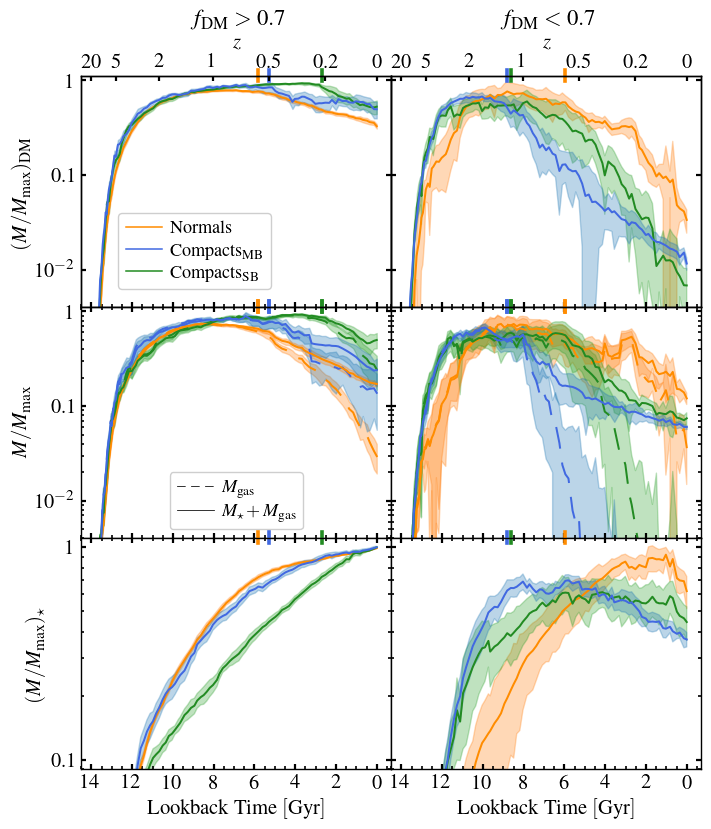

In [ ]:
plot.PlotMedianEvolution(['Normal','SBC', 'MBC'], ['SatelliteDMrich', 'SatelliteDMpoor'],  [['MDM_Norm_Max'],  ['Mgas_Norm_Max', 'Mbar_Norm_Max'], ['Mstar_Norm_Max']],
                     Type='Evolution', Xparam=['Time'], title=['DMrich', 'DMpoor'], 
                        xlabelintext=False, lineparams=True,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False, EntryMedian = True,
                        savepath='PaperII/PlotMedianEvolution',  savefigname='DMpoorMass', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC', 'SBC'], ['Mgas_Norm_Max', 'Mbar_Norm_Max']],
                        loc = [(0.12, 0.08), 'best', 'best'],  loctext = ['best'],
                        ylimmin = [0.004, 0.004, 0.09,], ylimmax = [1.1,1.1, 1.1], xlimmin = None, xlimmax = None,  
                        legpositions = [[0, 0], [0,1]], 
                        lNum = 3, cNum = 4,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=15,   nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

## Figure 7

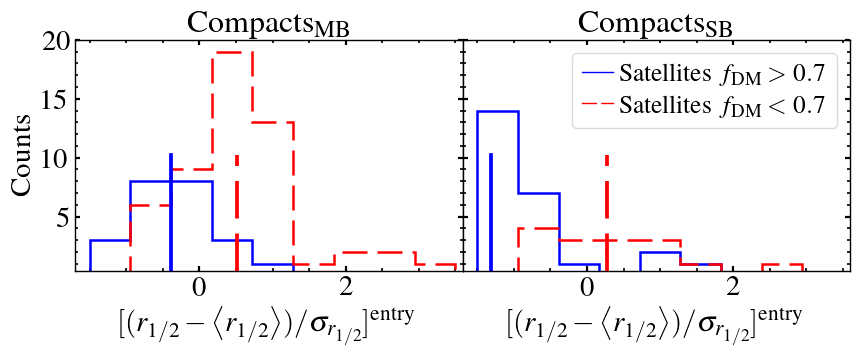

In [ ]:
plot.PlotHist(['SatelliteDMrich', 'SatelliteDMpoor'], ['MBC', 'SBC'],
              ['deltaSize_at_Entry'],   Type = 'Sample',
               savepath='PaperII/PlotHist',  savefigname='SizeDelta', dfName='PaperII', SampleName='SubfindID_99', 
                density=False, 
                ColumnPlot = True,  median=True,  legend = True,  legendColumn = True, GridMake = False,
                lNum = 3, cNum = 5, title = ['MBC', 'SBC'], 
                LegendNames = [['SatelliteDMrich', 'SatelliteDMpoor']], legpositions = [[1, 0]], #xlabelintext = ['SBC', 'MBC'], 
                ylimmin = [0.4, 0.4], ylimmax = [20, 20], xlimmin = [-1.7, -1.7], xlimmax = [3.6, 3.6],
                yscale = 'linear', TRANSPARENT = True, LookBackTime = True, loc = ['upper right'],
                fontlabel=21, linewidth =  1.9,
                framealpha=0.7, handlelength = 1.2, handletextpad = 0.3)

## Figure 8

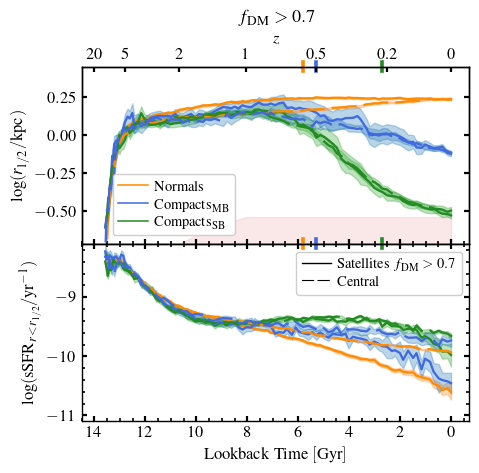

In [ ]:
plot.PlotMedianEvolution(['NormalSatelliteDMrich','SBCSatelliteDMrich', 'MBCSatelliteDMrich','NormalCentral', 'SBCCentral', 'MBCCentral'], [''],  ['SubhaloHalfmassRadType4',  'SubhalosSFRInHalfRad'], 
                     Type='Evolution', Xparam=['Time'], title=['DMrich'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII/PlotMedianEvolution',  savefigname='SizesSFR', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC', 'SBC'], ['SatelliteDMrichCO', 'CentralCO']],
                        loc = [(0.08, 0.05), 'best'],  loctext = ['best'], EntryMedian = True,
                        ylimmin = [-0.72, -11.1], ylimmax = [0.45, -8.1], xlimmin = None, xlimmax = None,  
                        legpositions = [[0, 0], [0,1]], 
                        lNum = 2.3, cNum = 5,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=12,   nboots=100,  
                        Supertitle_y = 0.99, Softening = True, columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

In [ ]:
plot.PlotMedianEvolution(['NormalSatelliteDMrich','SBCSatelliteDMrich', 'MBCSatelliteDMrich','NormalCentral', 'SBCCentral', 'MBCCentral'], [''],  ['sSFR_Ratio_05_2p5_pkpc'], 
                     Type='Evolution', Xparam=['Time'], title=['DMrich'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII/PlotMedianEvolution',  savefigname='Size_Test', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC', 'SBC'], ['SatelliteDMrichCO', 'CentralCO']],
                        loc = ['best'],  loctext = ['best'], EntryMedian = True,
                        #ylimmin = [-11.1, -11.1], ylimmax = [-8.1, -8.1], xlimmin = None, xlimmax = None,  
                        legpositions = [[0, 0], [0,1]], 
                        lNum = 2.3, cNum = 5,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=12,   nboots=100,  
                        Supertitle_y = 0.99, Softening = True, columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

## Figure 9

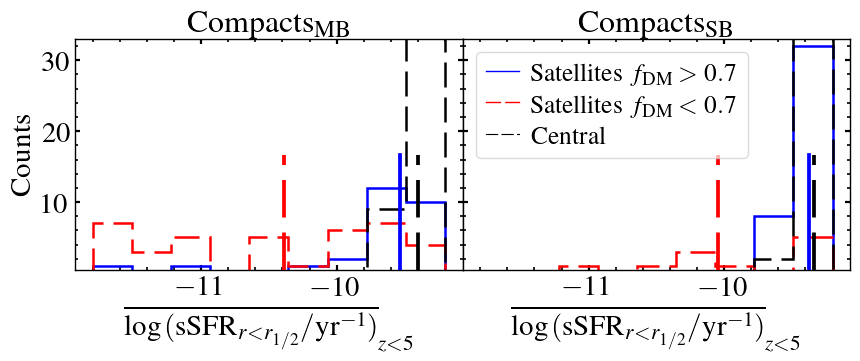

In [ ]:
plot.PlotHist(['SatelliteDMrich', 'SatelliteDMpoor', 'Central'], ['MBC', 'SBC'],
              ['sSFRinHalfRadAfterz5'],   Type = 'Sample',
               savepath='PaperII/PlotHist',  savefigname='sSFRCentrals', dfName='PaperII', SampleName='SubfindID_99', yscale = 'log',
                density=False, 
                ColumnPlot = True, bins=[[5, 5, 6]], median=True,  legend = True,  legendColumn = True, GridMake = False,
                lNum = 3, cNum = 5, title = ['MBC', 'SBC'], 
                LegendNames = [['SatelliteDMrich', 'SatelliteDMpoor', 'Central']], legpositions = [[1, 0]], loc = [(0.02,0.52)],
                ylimmin = [0.4, 0.4], ylimmax = [100, 100], #xlimmin = [-0.1, 10.2, 0.08], xlimmax = [3.5, 14.9, 9],
                 TRANSPARENT = True, LookBackTime = True, 
                fontlabel=21, handlelength = 1.75,
                framealpha=0.7, handletextpad = 0.45)

In [ ]:
TNG.compare_Sample_key('sSFRinHalfRadAfterz5', [['MBC_Satellite_DMrich', 'MBC_Central'],
                               ['SBC_Satellite_DMrich', 'SBC_Central'],
                               ['MBC_Satellite_DMpoor', 'MBC_Central'],
                               ['SBC_Satellite_DMpoor', 'SBC_Centralr']], dfName = 'PaperII')


MBC_Satellite_DMrich  and  MBC_Central
Medians:  -9.543 -9.402
Observed Test Statistic: 0.14122
Permutation Test P-Value: 0.0001
SBC_Satellite_DMrich  and  SBC_Central
Medians:  -9.374 -9.335
Observed Test Statistic: 0.03908
Permutation Test P-Value: 0.018
MBC_Satellite_DMpoor  and  MBC_Central
Medians:  -11.146 -9.402
Observed Test Statistic: 1.74378
Permutation Test P-Value: 0.0
SBC_Satellite_DMpoor  and  SBC_Centralr
Medians:  -10.192 -9.335
Observed Test Statistic: 0.85722
Permutation Test P-Value: 0.0


## Figure 10

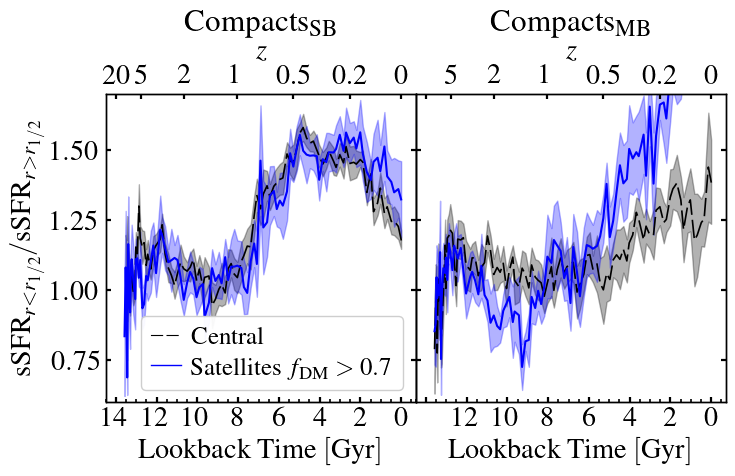

In [ ]:
plot.PlotMedianEvolution(['Central', 'SatelliteDMrich'], ['SBC', 'MBC'],  ['sSFRCoreRatio'], 
                     Type='Evolution', Xparam=['Time'], title=['SBC', 'MBC'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII/PlotMedianEvolution',  savefigname='sSFRRatioCentrals', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Central', 'SatelliteDMrich']],
                        loc = ['best'],  loctext = ['best'],
                        ylimmin = [0.6], ylimmax = [1.7], xlimmin = None, xlimmax = None,
                        legpositions = [[0, 0]],
                        lNum = 4, cNum = 4, SmallerScale= True,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=20.5,   nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3,  handlelength = 1.2, 
                        bins=10, seed=16040105)


## Figure 11

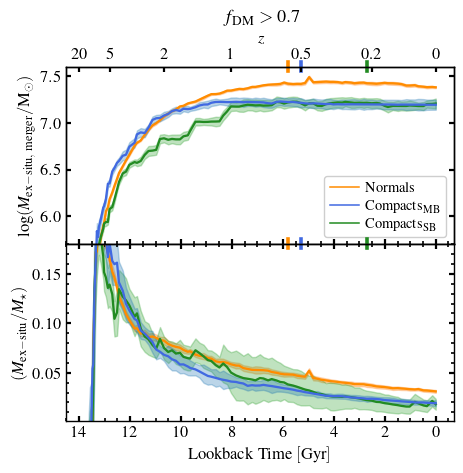

In [ ]:
plot.PlotMedianEvolution(['Normal','SBC', 'MBC'], ['SatelliteDMrich'], ['StellarMassExSitu',  'Frac_ExSitu'], 
                     Type='Evolution', Xparam=['Time'], title=['DMrich'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII/PlotMedianEvolution',  savefigname='ExSitu', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC', 'SBC'], ['SatelliteDMrichCO', 'CentralCO']],
                        loc = ['best'],  loctext = ['best'], EntryMedian = True,
                        ylimmin = [5.7, 0.09], ylimmax = [7.6, 0.18],
                        legpositions = [[0, 0]], 
                        lNum = 2.3, cNum = 5,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=12,   nboots=100,  
                        Supertitle_y = 0.99, Softening = True, columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

## Figure 12

Doesn't have  PartType0  at snap:  89
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  99
Doesn't have  PartType0  at snap:  71
Doesn't have  PartType0  at snap:  99
Doesn't have

NameError: name 'Line2D' is not defined

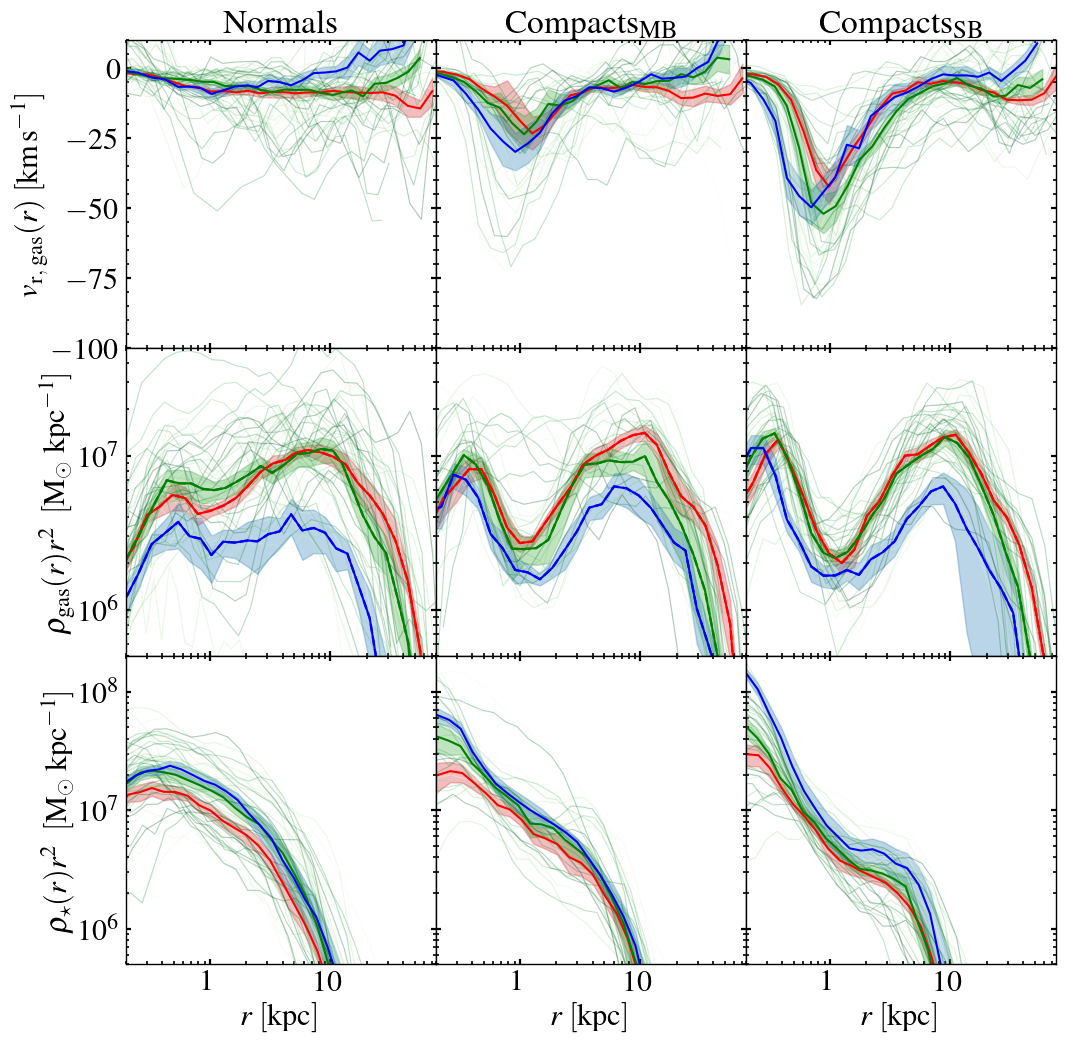

In [ ]:
IDs_SBCSatelliteDMrich = np.array([   91,    156,    165,  63918,  96799, 167427, 198195, 198199,
       264900, 319740, 324134, 355736, 379807, 439101, 440412, 468596,
       489208, 499708, 513846, 531321, 570842, 573063, 574616, 592022,
       616015, 618581, 625186, 629892, 649988, 661261, 667085, 668241,
       671097, 684712, 692883, 694489, 697154, 724892, 725997, 770775,
       804308])

IDs_SBCSatelliteDMpoor = np.array([63990,  64002,  96853, 117357, 229992, 229996, 294887, 294895,
                                   358627, 422770, 428191, 500583, 516761, 602132, 602133, 603556])

IDs_MBCSatelliteDMrich = np.array([550,  63973,  96789, 117311, 220616, 229958, 264932, 289394,
       300918, 307497, 307502, 342468, 372756, 419621, 422762, 435755,
       445628, 450924, 487746, 488533, 489207, 571909, 579511, 590015,
       597142, 681818, 701373, 814011, 823293])

IDs_MBCSatelliteDMpoor = np.array([232,    261,    281,    300,    319,    333,  63993,  64081,
        64129,  96941, 117464, 144008, 144098, 167499, 185005, 185058,
       208883, 220626, 242863, 253897, 253905, 253965, 264911, 264972,
       275601, 282802, 282807, 289444, 307510, 319738, 319743, 377662,
       386293, 394628, 404834, 421566, 421567, 422763, 425726, 432119,
       457435, 467420, 482157, 502998, 530853, 536657, 545439, 549748,
       549750, 558069, 571075, 571910, 588180, 647769])

IDs_NormalSatelliteDMrich = np.array([333431, 677786, 143950,    203,    147, 775527, 198247, 117291,
       427216, 198231, 770462, 117299, 386274, 471252, 800643,  63957,
       594247, 465257, 253882, 763684, 574885, 837220, 143967, 184962,
          423, 508541, 472552,    214, 749432, 184980,  63939, 184966,
       435760, 414921,    181, 345881, 229952, 282799, 264901, 117426,
       184984, 117314,  64009, 184982, 294884, 229984, 208826, 494014,
       433290, 198237])

IDs_NormalSatelliteDMpoor = np.array([184957, 220633, 338455, 436937, 560083, 586424, 602131, 603005])
#%%
fontlabel = 22
nboot = 5000
nbins = 30
plt.rcParams.update({'figure.figsize': (4*3, 4*3)})

fig = plt.figure()
gs = fig.add_gridspec(3, 3, hspace=0, wspace=0)
axs = gs.subplots(sharex='col', sharey='row')

Names = [r'Normals', r'Compacts$_\mathrm{MB}$', r'Compacts$_\mathrm{SB}$']
rmin = 0.06
rmax = 35


def plot_profile(ax, x, y, color, lw=1.5, ls='-', alpha=1.0, multiply_r2=False, label=None):
    """
    Plota apenas pontos válidos.
    """
    x = np.atleast_1d(np.array(x, dtype=float))
    y = np.atleast_1d(np.array(y, dtype=float))

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    if multiply_r2:
        mask &= (y > 0)

    if np.sum(mask) == 0:
        return

    xx = x[mask]
    yy = y[mask]

    if multiply_r2:
        yy = yy * xx**2

    ax.plot(xx, yy, color=color, lw=lw, ls=ls, alpha=alpha, label=label)


def fill_profile(ax, x, y, yerr, color, alpha=0.3, multiply_r2=False):
    """
    Fill_between apenas para pontos válidos.
    """
    x = np.atleast_1d(np.array(x, dtype=float))
    y = np.atleast_1d(np.array(y, dtype=float))
    yerr = np.atleast_1d(np.array(yerr, dtype=float))

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (x > 0)

    ylow = y - yerr
    yhigh = y + yerr

    if multiply_r2:
        mask &= (ylow > 0) & (yhigh > 0)
        if np.sum(mask) == 0:
            return
        ax.fill_between(
            x[mask],
            ylow[mask] * x[mask]**2,
            yhigh[mask] * x[mask]**2,
            color=color,
            alpha=alpha
        )
    else:
        if np.sum(mask) == 0:
            return
        ax.fill_between(
            x[mask],
            ylow[mask],
            yhigh[mask],
            color=color,
            alpha=alpha
        )


for j, PartType in enumerate(['PartType0', 'PartType0', 'PartType4']):

    if j == 0:
        velPlot = True
        gasSF = False
    elif j == 1:
        velPlot = False
        gasSF = False
    else:
        velPlot = False
        gasSF = False

    for linplot, IDs in enumerate([IDs_NormalSatelliteDMrich, IDs_MBCSatelliteDMrich, IDs_SBCSatelliteDMrich]):

        dFHalfStar = TNG.extractDF('SubhaloHalfmassRadType4')
        dFHalfGasRad = TNG.extractDF('SubhaloHalfmassRadType0')

        # -------------------------
        # SNAPS: t_entry - ~2 Gyr
        # -------------------------
        SnapsFirst = []
        for l, ID in enumerate(IDs):
            if ID == 603556 or ID == 602133:
                continue

            snapFirstEntry = PaperII.Snap_At_FirstEntry.loc[PaperII.SubfindID_99 == ID].values[0]
            if np.isnan(snapFirstEntry) or snapFirstEntry < 0:
                snapFirstEntry = 67

            snap = dfTime.loc[
                abs(dfTime.Age - dfTime.loc[dfTime.Snap == snapFirstEntry, 'Age'].values[0]) < 1.5,
                'Snap'
            ].values[-1]

            if snap < 17:
                snap = 17

            SnapsFirst.append(int(snap))

        xFirst, yFirst, yerrFirst, massFirst, xIDsFirst, yIDFirst, massIDsFirst, notIndex = \
            plot.MakeMedianAndIDs(
                SnapsFirst, IDs, rmin, rmax, nbins, PaperII,
                PartType=PartType, velPlot=velPlot, gasSF=gasSF
            )

        colors = plt.cm.Blues(np.linspace(0, 1, len(yIDFirst)))
        #plot.MakeLines(j, axs[j][linplot], yIDFirst, xIDsFirst, IDs, notIndex, colors)

        # -------------------------
        # SNAPS: t_entry
        # -------------------------
        Snaps = []
        for l, ID in enumerate(IDs):
            if ID == 603556 or ID == 602133:
                continue

            snapFirstEntry = PaperII.Snap_At_FirstEntry.loc[PaperII.SubfindID_99 == ID].values[0]
            if np.isnan(snapFirstEntry) or snapFirstEntry < 0:
                snapFirstEntry = 67

            Snaps.append(int(snapFirstEntry))

        xSecond, ySecond, yerrSecond, massSecond, xIDsSecond, yIDSecond, massIDsSecond, notIndex = \
            plot.MakeMedianAndIDs(
                Snaps, IDs, rmin, rmax, nbins, PaperII,
                PartType=PartType, velPlot=velPlot, gasSF=gasSF
            )

        colors = plt.cm.Greens(np.linspace(0, 1, len(yIDSecond)))
        plot.MakeLines(j, axs[j][linplot], yIDSecond, xIDsSecond, IDs, notIndex, colors)

        # -------------------------
        # SNAPS: t_entry + ~2 Gyr
        # -------------------------
        SnapsFinal = []
        for l, ID in enumerate(IDs):
            if ID == 603556 or ID == 602133:
                continue

            snapFirstEntry = PaperII.Snap_At_FirstEntry.loc[PaperII.SubfindID_99 == ID].values[0]
            if np.isnan(snapFirstEntry) or snapFirstEntry < 0:
                snapFirstEntry = 67

            if linplot == 1:
                snap = dfTime.loc[
                    abs(dfTime.Age - dfTime.loc[dfTime.Snap == snapFirstEntry, 'Age'].values[0]) < 2,
                    'Snap'
                ].values[0]
            else:
                snap = 99

            SnapsFinal.append(int(snap))

        xFinal, yFinal, yerrFinal, massFinal, xIDsFinal, yIDsFinal, massIDsFinal, notIndex = \
            plot.MakeMedianAndIDs(
                SnapsFinal, IDs, rmin, rmax, nbins, PaperII,
                PartType=PartType, velPlot=velPlot, gasSF=gasSF
            )

        colors = plt.cm.Reds(np.linspace(0, 1, len(yIDsFinal)))
        #plot.MakeLines(j, axs[j][linplot], yIDsFinal, xIDsFinal, IDs, notIndex, colors)

        # ==========================================================
        # PERFIS DE STAR-FORMING GAS APENAS PARA O PAINEL DO GÁS
        # ==========================================================
        if j == 1:
            xFirstSF, yFirstSF, yerrFirstSF, massFirstSF, xIDsFirstSF, yIDFirstSF, massIDsFirstSF, notIndexSF = \
                plot.MakeMedianAndIDs(
                    SnapsFirst, IDs, rmin, rmax, nbins, PaperII,
                    PartType='PartType0', velPlot=False, gasSF=True
                )

            xSecondSF, ySecondSF, yerrSecondSF, massSecondSF, xIDsSecondSF, yIDSecondSF, massIDsSecondSF, notIndexSF = \
                plot.MakeMedianAndIDs(
                    Snaps, IDs, rmin, rmax, nbins, PaperII,
                    PartType='PartType0', velPlot=False, gasSF=True
                )

            xFinalSF, yFinalSF, yerrFinalSF, massFinalSF, xIDsFinalSF, yIDsFinalSF, massIDsFinalSF, notIndexSF = \
                plot.MakeMedianAndIDs(
                    SnapsFinal, IDs, rmin, rmax, nbins, PaperII,
                    PartType='PartType0', velPlot=False, gasSF=True
                )

        # ==========================================================
        # PLOTS
        # ==========================================================
        if j == 1 or j == 2:
            # faixas do gás total / estrelas
            fill_profile(axs[j][linplot], xFirst,  yFirst,  yerrFirst,  color='tab:red',   alpha=0.3, multiply_r2=True)
            fill_profile(axs[j][linplot], xSecond, ySecond, yerrSecond, color='tab:green', alpha=0.3, multiply_r2=True)
            fill_profile(axs[j][linplot], xFinal,  yFinal,  yerrFinal,  color='tab:blue',  alpha=0.3, multiply_r2=True)

            # linhas sólidas: total gas / stars
            plot_profile(
                axs[j][linplot], xFirst, yFirst,
                color='red', lw=1.5, ls='-',
                multiply_r2=True,
                label=r'$t_\mathrm{entry} - 2 \, \mathrm{[Gyr]}$'
            )
            plot_profile(
                axs[j][linplot], xSecond, ySecond,
                color='green', lw=1.5, ls='-',
                multiply_r2=True,
                label=r'$t_\mathrm{entry}$'
            )
            plot_profile(
                axs[j][linplot], xFinal, yFinal,
                color='blue', lw=1.5, ls='-',
                multiply_r2=True,
                label=r'$t_\mathrm{entry} + 2 \, \mathrm{[Gyr]}$'
            )

            # linhas dashed: star-forming gas
            if j == 1:
                plot_profile(
                    axs[j][linplot], xFirstSF, yFirstSF,
                    color='red', lw=1.7, ls='--', alpha=1,
                    multiply_r2=True
                )
                plot_profile(
                    axs[j][linplot], xSecondSF, ySecondSF,
                    color='green', lw=1.7, ls='--', alpha=1,
                    multiply_r2=True
                )
                plot_profile(
                    axs[j][linplot], xFinalSF, yFinalSF,
                    color='blue', lw=1.7, ls='--', alpha=1,
                    multiply_r2=True
                )

        else:
            # painel de velocidade radial do gás
            fill_profile(axs[j][linplot], xFirst,  yFirst,  yerrFirst,  color='tab:red',   alpha=0.3, multiply_r2=False)
            fill_profile(axs[j][linplot], xSecond, ySecond, yerrSecond, color='tab:green', alpha=0.3, multiply_r2=False)
            fill_profile(axs[j][linplot], xFinal,  yFinal,  yerrFinal,  color='tab:blue',  alpha=0.3, multiply_r2=False)

            plot_profile(
                axs[j][linplot], xFirst, yFirst,
                color='red', lw=1.5, ls='-',
                multiply_r2=False,
                label=r'$t_\mathrm{entry} - 2 \, \mathrm{[Gyr]}$'
            )
            plot_profile(
                axs[j][linplot], xSecond, ySecond,
                color='green', lw=1.5, ls='-',
                multiply_r2=False,
                label=r'$t_\mathrm{entry}$'
            )
            plot_profile(
                axs[j][linplot], xFinal, yFinal,
                color='blue', lw=1.5, ls='-',
                multiply_r2=False,
                label=r'$t_\mathrm{entry} + 2 \, \mathrm{[Gyr]}$'
            )

        # ==========================================================
        # ESTILO DOS EIXOS
        # ==========================================================
        if j == 0:
            axs[j][linplot].set_title(Names[linplot], fontsize=1.1 * fontlabel)

        if j != 0:
            axs[j][linplot].set_yscale('log')

        axs[j][linplot].set_xscale('log')
        axs[j][linplot].set_xlim(0.2, 75)

        if j == 0:
            axs[j][linplot].set_ylim(-100, 10)
        elif j == 1:
            axs[j][linplot].set_ylim(5e5, 5e7)
        else:
            axs[j][linplot].set_ylim(5e5, 2e8)

        if j == 2:
            axs[j][linplot].tick_params(axis='x', labelsize=0.99 * fontlabel)

        if linplot == 0:
            axs[j][linplot].tick_params(axis='y', labelsize=0.99 * fontlabel)

            if j == 2:
                axs[j][linplot].set_ylabel(
                    r'$\rho_{\star} (r) r^2  \; \, \, [\mathrm{M_\odot  \; kpc^{-1}}]$',
                    fontsize=fontlabel
                )
            elif j == 1:
                axs[j][linplot].set_ylabel(
                    r'$\rho_{\mathrm{gas}} (r) r^2  \; \, \, [\mathrm{M_\odot  \; kpc^{-1}}]$',
                    fontsize=fontlabel
                )
            else:
                axs[j][linplot].set_ylabel(
                    r'$v_\mathrm{r, \; gas} (r) \, \, [\mathrm{km \, s}^{-1}]$',
                    fontsize=fontlabel
                )

        if j == 2:
            axs[j][linplot].set_xlabel(r'$r  \; [\mathrm{kpc}]$', fontsize=fontlabel)

        if j != 0:
            axs[j][linplot].yaxis.set_major_formatter(
                plot.FuncFormatter(plot.format_func_loglog)
            )

        axs[j][linplot].xaxis.set_major_formatter(
            plot.FuncFormatter(plot.format_func_loglog)
        )

# ==========================================================
# LEGENDAS
# ==========================================================
time_handles = [
    Line2D([0], [0], color='red',   lw=1.5, ls='-', label=r'$t_\mathrm{entry} - 2 \, \mathrm{[Gyr]}$'),
    Line2D([0], [0], color='green', lw=1.5, ls='-', label=r'$t_\mathrm{entry}$'),
    Line2D([0], [0], color='blue',  lw=1.5, ls='-', label=r'$t_\mathrm{entry} + 2 \, \mathrm{[Gyr]}$')
]

style_handles = [
    Line2D([0], [0], color='black', lw=1.5, ls='-',  label='Total gas'),
    Line2D([0], [0], color='black', lw=1.2, ls='--', label='Star-forming gas')
]

leg1 = axs[0][0].legend(handles=time_handles, fontsize=0.9 * fontlabel, framealpha=0.4, loc='lower right')
axs[0][0].add_artist(leg1)

axs[1][2].legend(handles=style_handles, fontsize=0.75 * fontlabel, framealpha=0.4, loc='upper right')

plt.savefig(os.getenv("HOME") + '/TNG_Analyzes/Figs/ProfilesTest.pdf', bbox_inches='tight')
# plt.ylim(- 0.99, 0.99)



## Figure 13

royalblue MBC
forestgreen SBC


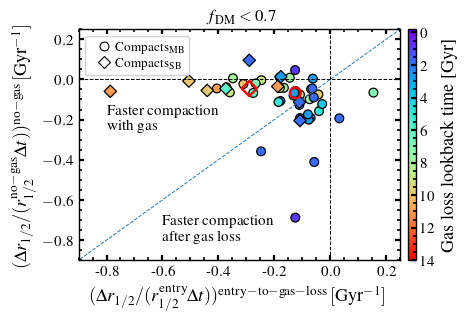

In [ ]:
plot.PlotScatter(['MBC', 'SBC'], ['SatelliteDMpoorLoseTheirGas'], 'Decrease_Entry_To_NoGas_Norm_Delta', 'Decrease_NoGas_To_Final_Norm_Delta',  Type='z0', snap=[99],
 title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False,
                legend=True, LegendNames=[['MBCColorbarBlackLineScatter', 'SBCColorbarBlackLineScatter']],  TRANSPARENT = False,  
                COLORBAR = ['SnapLostGas'], 
                cmap = 'rainbow_r',
                medianDot = True, 
                alphaScater=1.,  linewidth=0.7, 
                fontlabel=11,
                m='o', msizet=5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 3, cNum = 5,  EqualLine = True, EqualLineMin = -1., EqualLineMax = 0.3
                ,
                ylimmin = [-0.9], ylimmax = [0.25], xlimmin = [-0.9], xlimmax = [0.25],  
                legpositions = [[0, 0]],
                columnspacing = 0.5, handletextpad = -0.2, labelspacing = 0.3, loc = ['best'],
                savepath='PaperII/PlotScatter',  savefigname='DeltaR_Orb', dfName='PaperII', SampleName='Samples',
                bins=10, seed=16010504, mult = 4.1)

## Figure 14

In [ ]:

MBCIDs = np.array([   232,    261,    281,    300,    319,    333,  63993,  64081,
        64129,  96941, 117464, 144008, 144098, 167499, 185005, 185058,
       208883, 220626, 242863, 253897, 253905, 253965, 264911, 264972,
       275601, 282802, 282807, 289444, 307510, 319738, 319743, 377662,
       386293, 394628, 404834, 421566, 421567, 422763, 425726, 432119,
       457435, 467420, 482157, 502998, 530853, 536657, 545439, 549748,
       549750, 558069, 571075, 571910, 588180, 647769])
SBCIDs = np.array([ 63990,  64002,  96853, 117357, 229992, 229996, 294887, 294895,
       358627, 422770, 428191, 500583, 516761, 602132, 602133, 603556])


In [ ]:
fontlabel = 15
nboot = 5000
nbins = 25
plt.rcParams.update({'figure.figsize': (4*2, 3*2)})
fig = plt.figure()
gs = fig.add_gridspec(2, 2, hspace=0, wspace=0)
axs = gs.subplots(sharex='col', sharey='row')
Names = [r'Compacts$_\mathrm{MB}$', r'Compacts$_\mathrm{SB}$']
rmin = 0.1
rmax = 35
for linplot, IDs in enumerate([ MBCIDs, SBCIDs]):
    
    dFHalfStar = TNG.extractDF('SubhaloHalfmassRadType4')
    dFHalfGasRad = TNG.extractDF('SubhaloHalfmassRadType0')
    yIDsEntry = np.array([])
    massIDsEntry = np.array([])
    xIDsEntry = np.array([])
    notIndex = np.array([])
    for l, ID in enumerate(IDs):
        print(ID)
        if ID == 603556 or ID == 602133 :
            continue
        snap = PaperII.Snap_At_FirstEntry.loc[PaperII.SubfindID_99 == ID].values[0]
        if np.isnan(snap):
            continue
        snap = int(snap)
        print('snap: ', snap)
        yrad, rad, mass = TNG.MakeDensityProfileMean(snap, ID, rmin, rmax, nbins)
        
        if len(yrad) == 1 or (ID == 603556 or ID == 602133):
            notIndex = np.append(notIndex, l)
            continue
        if l == 0 or len(yIDsEntry) == 0:
            yIDsEntry = np.append(yIDsEntry, yrad)
            xIDsEntry = np.append(xIDsEntry, rad)
            massIDsEntry = np.append(massIDsEntry, mass)
    
        else:
            yIDsEntry = np.vstack((yIDsEntry, yrad))
            massIDsEntry = np.vstack((massIDsEntry, mass))
            xIDsEntry = np.vstack((xIDsEntry, rad))
           
    
        Rvalues = xIDsEntry.T
        Values = yIDsEntry.T
        Masses = massIDsEntry.T

    x = np.array([])
    y = np.array([])
    mass = np.array([])
    
    
    
    if len(Values) > 0:
        if len(Values.shape) > 1:
            for k, value in enumerate(Values):
                x = np.append(x, np.nanmedian(Rvalues[k]))
                y = np.append(y, np.nanmedian(value))
                mass = np.append(mass, np.nanmedian(Masses[k]))
        else:
            x = Rvalues
            y = Values
            mass = Masses

    else:
        x = np.nan
        y = np.nan
        mass = np.nan
            
    xEntry = x
    yEntry = y
    massEntry = mass
      
    yIDs = np.array([])
    xIDs = np.array([])
    massIDs = np.array([])


    for l, ID in enumerate(IDs):  
     
        snap = 99
        yrad, rad, mass = TNG.MakeDensityProfileMean(snap, ID, rmin, rmax, nbins)
        if len(yrad) == 1 or (ID == 603556 or ID == 602133):
            notIndex = np.append(notIndex, l)
            continue
        if l == 0 or len(yIDs) == 0:
            yIDs = np.append(yIDs, yrad)
            xIDs = np.append(xIDs, rad)
            massIDs = np.append(massIDs, mass)

    
        else:
            yIDs = np.vstack((yIDs, yrad))
            xIDs = np.vstack((xIDs, rad))
            massIDs = np.vstack((massIDs, mass))

        Rvalues = xIDs.T
        Values = yIDs.T
        Masses = massIDs.T

    x = np.array([])
    y = np.array([])
    mass = np.array([])
    
    
    
    if len(Values) > 0:
        if len(Values.shape) > 1:
            for k, value in enumerate(Values):
                x = np.append(x, np.nanmedian(Rvalues[k]))
                y = np.append(y, np.nanmedian(value))
                mass = np.append(mass, np.nanmedian(Masses[k]))
        else:
            x = Rvalues
            y = Values
            mass = Masses

    else:
        x = np.nan
        y = np.nan
        mass = np.nan
            
    x99 = x
    y99 = y
    mass99 = mass



    colors = plt.cm.OrRd(np.linspace(0,1,len(yIDsEntry)))
    k = 0
    for l, ID in enumerate(IDs):
        if l in notIndex:
            continue
        value = yIDsEntry[k]
        axs[0][linplot].plot(xIDsEntry[k][massIDsEntry[k] > 0] , np.nancumsum(massIDsEntry[k][massIDsEntry[k] > 0])  , 
                             lw = 0.55,  alpha = 0.2, color = colors[k])

        axs[1][linplot].plot(xIDsEntry[k][value > 0] , value[value > 0] * xIDsEntry[k][value > 0]**2., 
                             lw = 0.55,  alpha = 0.2,  color = colors[k])
        
        k = k+ 1

     
    colors = plt.cm.Purples(np.linspace(0,1,len(yIDs)))
    k = 0
    for l, ID in enumerate(IDs):
        if l in notIndex:
            continue
        value = yIDs[k]
        axs[0][linplot].plot(xIDs[k][massIDs[k] > 0] , np.nancumsum(massIDs[k][massIDs[k] > 0]) , 
                             lw = 0.55, alpha = 0.25,  color = colors[k])   
        axs[1][linplot].plot(xIDs[k][value > 0] , value[value > 0] * xIDs[k][value > 0]**2., 
                             lw = 0.55,alpha = 0.2,  color = colors[k])  
        
        k = k + 1

    axs[1][linplot].plot(xEntry , yEntry*xEntry**2, color = 'firebrick', lw = 2.1, label = r'$z_\mathrm{entry}$')
    axs[1][linplot].plot(x99 , y99*x99**2, color = 'midnightblue', lw = 2.1, label = r'$z = 0$')   
  
    axs[0][linplot].plot(xEntry[massEntry > 0] , np.nancumsum(massEntry[massEntry > 0]) , color = 'firebrick', lw = 2.1, label = r'$z_\mathrm{entry}$')
    axs[0][linplot].plot(x99[mass99 > 0] , np.nancumsum(mass99[mass99 > 0]), color = 'midnightblue', lw = 2.1, label = r'$z = 0$')     
  
    
    axs[0][linplot].set_title(Names[linplot], fontsize=1.1*fontlabel)
    axs[0][linplot].set_xscale('log')
    axs[0][linplot].set_yscale('log')
    axs[1][linplot].set_yscale('log')
    
    axs[0][linplot].set_xlim(0.2, 75)
    axs[1][linplot].set_xlim(0.2, 75)
    axs[0][linplot].set_ylim(2e6, 6e9)
    axs[1][linplot].set_ylim(2e4, 2e8)
    
    axs[1][linplot].tick_params(axis='x', labelsize=0.99*fontlabel)

    axs[0][linplot].axhline(np.nansum(massEntry[massEntry > 0]) / 2., ls = '--', color = 'firebrick')


    if linplot == 0:
        axs[1][linplot].tick_params(axis='y', labelsize=0.99*fontlabel)
        axs[0][linplot].set_ylabel(r'$M_\star (<r) \; [\mathrm{M}_\odot]$', fontsize=fontlabel)
        axs[1][linplot].set_ylabel(r'$\rho_{\star} (r) r^2  \; \, \, [\mathrm{M_\odot  \; kpc^{-1}}]$', fontsize=fontlabel)
    axs[1][linplot].set_xlabel(r'$r  \; [\mathrm{kpc}]$', fontsize=fontlabel)
    
    
    axs[1][linplot].yaxis.set_major_formatter(
        plot.FuncFormatter(plot.format_func_loglog))
    axs[0][linplot].yaxis.set_major_formatter(
        plot.FuncFormatter(plot.format_func_loglog))
    axs[1][linplot].xaxis.set_major_formatter(
        plot.FuncFormatter(plot.format_func_loglog))
    axs[0][0].legend(handlelength = 1.2 ,fontsize=0.9*fontlabel, framealpha = 0.4)

plt.savefig(os.getenv("HOME")+'/TNG_Analyzes/Figs/Profiles.pdf', bbox_inches='tight')    
#plt.ylim(- 0.99, 0.99)


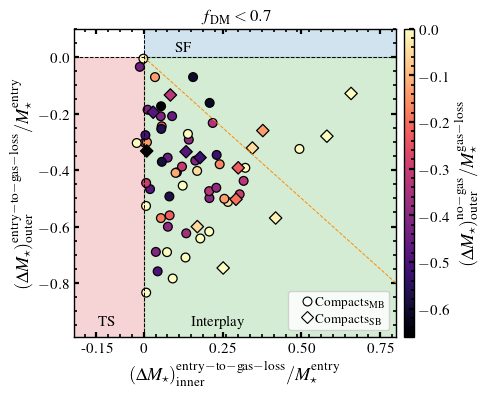

In [ ]:
plot.PlotScatter(['MBC', 'SBC'], ['SatelliteDMpoor'], 'MassIn_Infall_to_GasLost', 'MassAboveAfter_Infall_to_GasLost',  Type='z0', snap=[99],
 title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False,
                legend=True, LegendNames=[['MBCColorbarBlackLineScatter', 'SBCColorbarBlackLineScatter']],  TRANSPARENT = False,  COLORBAR = ['MassAboveAfterInfall_Lost'], 
                cmap = 'magma',
                medianDot = False, 
                alphaScater=1.,    linewidth=0.7,  ratioColorbar = 30,
                fontlabel=11,
                m='o', msizet=5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None,
                lNum = 4, cNum = 5,
                ylimmin = [-0.99], ylimmax = [0.1], xlimmin = [-0.22], xlimmax = [0.8],  
                legpositions = [[0, 0]],
                columnspacing = 0.5, handletextpad = -0.4, labelspacing = 0.3, loc = ['lower right'],
                savepath='PaperII/PlotScatter',  savefigname='MassIn_Out', dfName='PaperII', SampleName='Samples',
                bins=10, seed=16010504, mult = 4.1)

## Figure 15

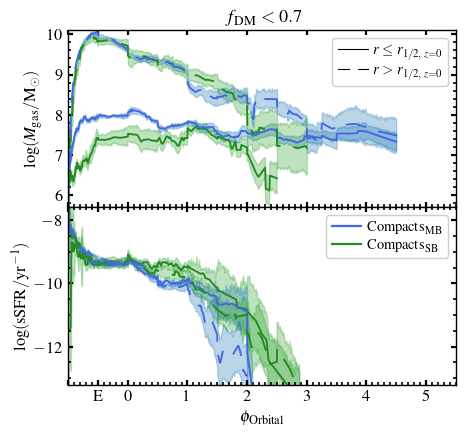

In [ ]:
plot.PlotMedianEvolution(['SBC', 'MBC'], ['SatelliteDMpoor'],  [['GasMass_In_TrueRhpkpc', 'GasMass_Above_TrueRhpkpc'], ['sSFR_In_TrueRhpkpc', 'sSFR_Above_TrueRhpkpc']], 
                     Type='Evolution', Xparam=['Time'], title=['DMpoor'], PhasingPlot = True, xPhaseLim = 5,
                        xlabelintext=False, lineparams=True,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII/PlotMedianEvolution',  savefigname='GasInnerOuterTrue', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[ ['GasMass_In_TrueRhpkpc', 'GasMass_Above_TrueRhpkpc'], [ 'MBC', 'SBC']],
                        loc = ['best', 'best' ],  loctext = ['best', 'best'],
                        legpositions = [[0, 0], [0,1]],
                        lNum = 2.3, cNum = 5,
                        ylimmin = [5.7, -13.2], ylimmax = [10.1, -7.6],
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,    fontlabel=12,   nboots=100,  
                        Supertitle_y = 0.99,  columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)

## Figure 16

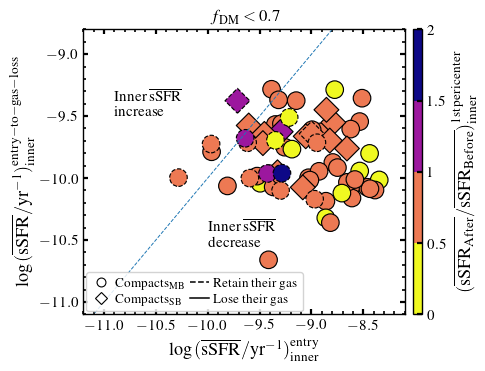

In [ ]:
plot.PlotScatter(['MBCLoseTheirGas', 'SBCLoseTheirGas', 'SBCDontLoseTheirGas', 'MBCDontLoseTheirGas'], ['SatelliteDMpoor'], 'sSFRTrueInner_BeforeEntry', ['sSFRTrueInner_Entry_to_Nogas'],  Type='z0', snap=[99],
title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False, COLORBAR = ['sSFRRatioPericenter'],
               legend=True,LegendNames=[[ 'MBCColorbarBlackLineScatter', 'SBCColorbarBlackLineScatter', 'DontLoseTheirGasBlackLineScatter', 'LoseTheirGasBlackLineScatter',]], TRANSPARENT = False,  
               cmap = 'plasma_r',
               alphaScater=1.,   alphaShade=0.3,  linewidth=0.7, 
               fontlabel=11,
               m='o', msizet=5, quantile=0.95,framealpha = 0.85, q = 0.95,
               MarkerSizes = None,
               lNum = 3.7, cNum = 5,
               legpositions = [[0, 0]],   ratioColorbar = 30,
               ylimmin = [-11.1], ylimmax = [-9.1],xlimmin = [-11.2], xlimmax = [-8.1],
               columnspacing = 0.5, handletextpad = 0.3, labelspacing = 0.3, loc = [(0.01, 0.01)],
               savepath='PaperII/PlotScatter',  savefigname='sSFR_Check', dfName='PaperII', SampleName='Samples', handlelength = 1.4,
               bins=10, seed=16010504, mult = 4.1)

## Figure 17

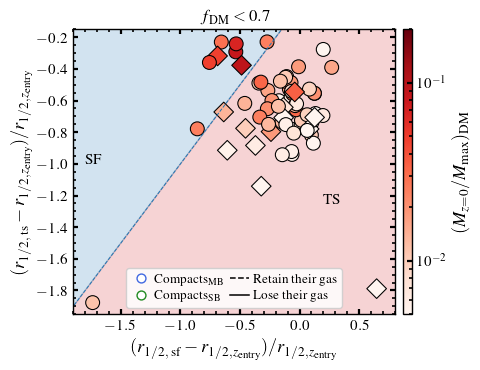

In [ ]:
plot.PlotScatter(['MBCLoseTheirGas', 'SBCLoseTheirGas', 'SBCDontLoseTheirGas', 'MBCDontLoseTheirGas'], ['SatelliteDMpoor'], 'Relative_Rhalf_MaxProfile_Minus_HalfRadstar_Entry', 
                 ['Relative_Rhalf_MinProfile_Minus_HalfRadstar_Entry'],  Type='z0', snap=[99], COLORBAR = ['MDM_Norm_Max_99'],
title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False, 
               legend=True,LegendNames=[[ 'MBCEmptyScatter', 'SBCEmptyScatter', 'DontLoseTheirGasBlackLineScatter', 'LoseTheirGasBlackLineScatter',]], TRANSPARENT = False,  
               cmap = 'Reds',
               alphaScater=1.,   alphaShade=0.3,  linewidth=0.7, 
               fontlabel=11,
               m='o', msizet=5, quantile=0.95,framealpha = 0.85, q = 0.95,
               ylimmin = [-1.95], ylimmax = [-0.15],xlimmin = [-1.9], xlimmax = [0.8],
               MarkerSizes = None,
               lNum = 3.7, cNum = 5,
               legpositions = [[0, 0]],
               columnspacing = 0.5, handletextpad = 0.3, labelspacing = 0.3, loc = ['lower center'],  ratioColorbar = 30, handlelength = 1.4,
               savepath='PaperII/PlotScatter',  savefigname='Rhalf_New', dfName='PaperII', SampleName='Samples',
               bins=10, seed=16010504, mult = 4.1)

## Figure 18

In [ ]:
IDs = [422770, 467420, 117464, 436937]

IDsName = ['ID: 422770 \n Compact$_\mathrm{SB}$',  'ID: 467420 \n Compact$_\mathrm{MB}$', 'ID: 117464 \n Compact$_\mathrm{MB}$', 'ID: 436937 \n Normal']

plot.PlotIDsColumns(IDs, [[  'SubhaloHalfmassRadType4'],['Mgas_Norm_Max', 'MDM_Norm_Max', 'Mstar_Norm_Max'], 
                           ['sSFR_In_Rhpkpc', 'sSFR_Above_Rhpkpc'], 
                          ['StarMass_In_Rhpkpc', 'StarMass_Above_Rhpkpc'], ['r_over_R_Crit200', 'r_over_R_Crit200_FirstGroup']], dataMarker=None, dataLine=None,  
                  title=IDsName, xlabelintext=False, lineparams=False,  QuantileError=True, 
           alphaShade=0.3,  linewidth=1.1, fontlabel=26.5,  nboots=100,  ColumnPlot=False, limaxis=False, 
           columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3,  Pericenter = False, postext = ['best'],
           lNum = 7, cNum = 3.7,
           NoGas = False, InfallTime = True, GridMake = False,
           ylimmin = [ -0.615, 0.008, -10.9, 6.5, 0.05], ylimmax = [0.54, 1.1, -7.8,  9.8, 25],
           SmallerScale = True,
           Type='Evolution', Xparam='Time', savepath='PaperII/PlotIDColumns', savefigname='Cases_LIMITED', dfName='PaperII', SampleName='Samples',
             legend=True, LegendNames='None',  loc='best', LookBackTime = True,
           bins=10, seed=16010504, TRANSPARENT = False, Softening = False, MaxSizeType = False)

AttributeError: module 'PlotFunctions' has no attribute 'PlotIDsColumns'

## Figure 19

SatelliteDMrich: 0.9693355560302734
SatelliteDMpoor: 1.7243141348266606
Central: 0.4538936614990234
SatelliteDMrich: 0.4586124420166015
SatelliteDMpoor: 1.610814094543457
Central: 0.337921142578125


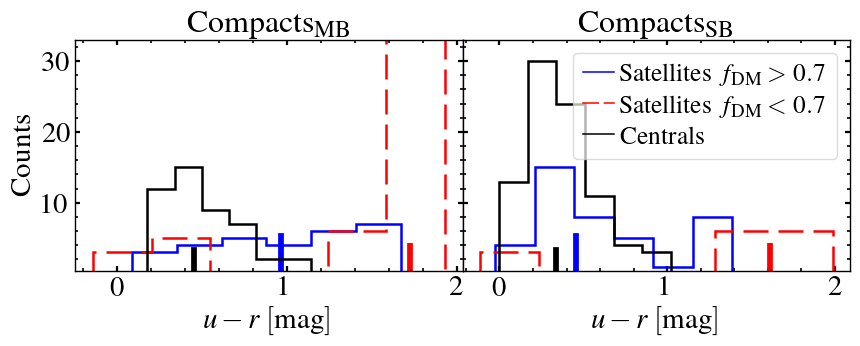

In [ ]:
plot.PlotHist(['SatelliteDMrich', 'SatelliteDMpoor', 'Central'], ['MBC', 'SBC'],
              ['U-r'],   Type = 'Sample',
               savepath='PaperII/PlotHist',  savefigname='Color', dfName='PaperII', SampleName='SubfindID_99', 
                density=False, 
                ColumnPlot = True, bins=[[6, 6, 6]], median=True,  legend = True,  legendColumn = True, GridMake = False,
                lNum = 3, cNum = 5, title = ['MBC', 'SBC'], 
                LegendNames = [['SatelliteDMrich', 'SatelliteDMpoor', 'Central']], legpositions = [[0, 0]], loc = [(0.02, 0.53)],
                ylimmin = [0.4, 0.4], ylimmax = [50, 50], #xlimmin = [-0.1, 10.2, 0.08], xlimmax = [3.5, 14.9, 9],
                yscale = 'linear', TRANSPARENT = True, LookBackTime = True, 
                fontlabel=21,
                framealpha=0.7, handlelength = 1.75, handletextpad = 0.25)

## Figure 20

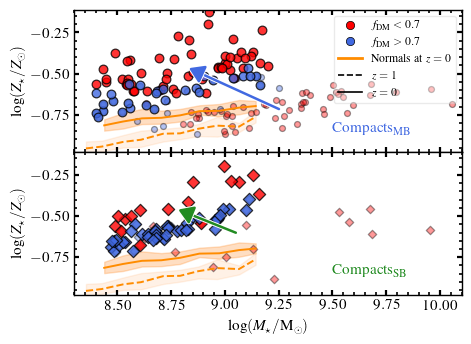

In [ ]:
import matplotlib.patheffects as pe
fig = plt.figure()
plt.rcParams.update({'figure.figsize': (5, 5)})
gs = fig.add_gridspec(2, 1, hspace=0, wspace=0)
axs = gs.subplots(sharex='col', sharey='row')

Zsun =  0.0127 
SBCSatellite = TNG.extractPopulation('SBCSatellite', dfName = 'PaperII')
MBCSatellite = TNG.extractPopulation('MBCSatellite',  dfName = 'PaperII')
NormalSatellite = TNG.extractPopulation('NormalSatellite',  dfName = 'PaperII')

XSBCMax = np.array([v for v in SBCSatellite.MaxStellarMassInRad[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])
YSBC = np.log10( np.array([v for v in SBCSatellite.StarMetallicity_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])/ Zsun  ) - 0.75
XSBC = np.array([v for v in SBCSatellite.logMstarRad_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])
YSBCMax = np.log10(np.array([v for v in SBCSatellite.MaxStarMetallicity[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
DMSBC = np.array([v for v in SBCSatellite.DMFrac_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])


XMBCMax = np.array([v for v in MBCSatellite.MaxStellarMassInRad[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])
YMBC = np.log10(np.array([v for v in MBCSatellite.StarMetallicity_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
XMBC = np.array([v for v in MBCSatellite.logMstarRad_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])
YMBCMax = np.log10(np.array([v for v in MBCSatellite.MaxStarMetallicity[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
DMMBC = np.array([v for v in MBCSatellite.DMFrac_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])

XNormalMax = np.array([v for v in NormalSatellite.MaxStellarMassInRad[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values])
YNormal = np.log10(np.array([v for v in NormalSatellite.StarMetallicity_99[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
XNormal = np.array([v for v in NormalSatellite.logMstarRad_99[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values])
YNormalMax = np.log10(np.array([v for v in NormalSatellite.MaxStarMetallicity[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values]) / Zsun) - 0.75

YNormal_50 = np.array([v for v in NormalSatellite.StarMetallicity_50.values]) - 0.75
XNormal_50 = np.array([v for v in NormalSatellite.logMstarRad_50.values])


def draw_median_arrow(ax, x0, y0, x1, y1, mask, color):
    if np.sum(mask) == 0:
        return

    x0m = np.median(x0[mask])
    y0m = np.median(y0[mask])
    x1m = np.median(x1[mask])
    y1m = np.median(y1[mask])

    
    prop = dict(
        arrowstyle="-|>,head_width=0.35,head_length=0.55",
        facecolor=color,
        edgecolor=color,
        lw=1.8,
        shrinkA=0,
        shrinkB=0,
        alpha=1.0,
        mutation_scale=16,
    )
    
    ann = ax.annotate(
        "",
        xy=(x1m, y1m),
        xytext=(x0m, y0m),
        arrowprops=prop,
        zorder=30,
    )
    
    ann.arrow_patch.set_path_effects([
        pe.Stroke(linewidth=3.2, foreground='white'),
        pe.Normal()
    ])
    ann.arrow_patch.set_zorder(30)

poor_sbc = DMSBC < 0.7
rich_sbc = DMSBC > 0.7
poor_mbc = DMMBC < 0.7
rich_mbc = DMMBC > 0.7

# ---------------------------
# Robust median tracks for Normals
# replace the current "Define bins for x" + "HIGHER REDSHIFT" blocks by this
# ---------------------------

def get_binned_median_track(x, y, bins, min_count=5, qlo=25, qhi=75):
    x = np.asarray(x)
    y = np.asarray(y)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    idx = np.digitize(x, bins) - 1

    x_track = []
    y_med = []
    y_lo  = []
    y_hi  = []

    for i in range(len(bins) - 1):
        m = idx == i
        if np.sum(m) < min_count:
            continue

        xb = x[m]
        yb = y[m]

        x_track.append(np.median(xb))          # more robust than fixed bin center
        y_med.append(np.median(yb))
        y_lo.append(np.percentile(yb, qlo))
        y_hi.append(np.percentile(yb, qhi))

    return np.array(x_track), np.array(y_med), np.array(y_lo), np.array(y_hi)


# robust masks
mask_norm_99 = (
    (NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99).values &
    np.isfinite(NormalSatellite.logMstarRad_99.values) &
    np.isfinite(NormalSatellite.StarMetallicity_99.values) &
    (NormalSatellite.StarMetallicity_99.values > 0)
)

mask_norm_50 = (
    np.isfinite(NormalSatellite.logMstarRad_50.values) &
    np.isfinite(NormalSatellite.StarMetallicity_50.values) 
)

# redefine Normal tracks consistently
XNormal = NormalSatellite.logMstarRad_99.values[mask_norm_99]
YNormal = np.log10(NormalSatellite.StarMetallicity_99.values[mask_norm_99] / Zsun) - 0.75

XNormal_50 = NormalSatellite.logMstarRad_50.values
YNormal_50 = NormalSatellite.StarMetallicity_50.values - 0.75

# same bins for z=0 and z~1
num_bins = 20
xmin = np.nanmin(np.concatenate([XNormal, XNormal_50]))
xmax = np.nanmax(np.concatenate([XNormal, XNormal_50]))
bins = np.linspace(8.3, 10.1, num_bins + 1)

xmed_0, ymed_0, ylo_0, yhi_0 = get_binned_median_track(
    XNormal, YNormal, bins, min_count=5, qlo=25, qhi=75
)

xmed_50, ymed_50, ylo_50, yhi_50 = get_binned_median_track(
    XNormal_50, YNormal_50, bins, min_count=5, qlo=25, qhi=75
)

# z = 0
axs[1].plot(xmed_0, ymed_0, color='darkorange', lw=1.4, label='Normal population at $z=0$')
axs[1].fill_between(xmed_0, ylo_0, yhi_0, color='tab:orange', alpha=0.25)

axs[0].plot(xmed_0, ymed_0, color='darkorange', lw=1.4, label='Normal population at $z=0$')
axs[0].fill_between(xmed_0, ylo_0, yhi_0, color='tab:orange', alpha=0.25)

# z ~ 1 (Max)
axs[1].plot(xmed_50, ymed_50, color='darkorange', ls='--', lw=1.4, label='Normal population at $z\\sim1$')
axs[0].plot(xmed_50, ymed_50, color='darkorange', ls='--', lw=1.4, label='Normal population at $z\\sim1$')

# optional: if you also want a lighter shaded region for z~1, uncomment below
axs[1].fill_between(xmed_50, ylo_50, yhi_50, color='tab:orange', alpha=0.10)
axs[0].fill_between(xmed_50, ylo_50, yhi_50, color='tab:orange', alpha=0.10)


# MAXIMUM (smaller / lighter markers)
axs[1].scatter(XSBCMax[poor_sbc],
            YSBCMax[poor_sbc],
            color='red',
            edgecolor='k', alpha=.4,
            lw = 0.9,
            marker='D',
            ls = 'solid',
            s=2.8*6.5)

axs[1].scatter(XSBCMax[rich_sbc],
            YSBCMax[rich_sbc],
            color='royalblue',
            edgecolor='k', alpha=.4,
            lw = 0.9,
            marker='D',
            ls = 'solid',
            s=2.8*6.5)

axs[0].scatter(XMBCMax[poor_mbc],
            YMBCMax[poor_mbc],
            color='red',
            edgecolor='k', alpha=.4,
            lw = 0.9,
            marker='o',
            ls = 'solid',
            s=2.8*6.5)

axs[0].scatter(XMBCMax[rich_mbc],
            YMBCMax[rich_mbc],
            color='royalblue',
            edgecolor='k', alpha=.4,
            lw = 0.9,
            marker='o',
            ls = 'solid',
            s=2.8*6.5)

# z = 0 (larger / darker markers)
axs[1].scatter(XSBC[poor_sbc],
            YSBC[poor_sbc],
            color='red',
            edgecolor='k', alpha=.8,
            lw = 0.9,
            marker='D',
            s=6*6.5)

axs[1].scatter(XSBC[rich_sbc],
            YSBC[rich_sbc],
            color='royalblue',
            edgecolor='k', alpha=.8,
            lw = 0.9,
            marker='D',
            s=6*6.5)

axs[0].scatter(XMBC[poor_mbc],
            YMBC[poor_mbc],
            color='red',
            edgecolor='k', alpha=.8,
            lw = 0.9,
            marker='o',
            s=6*6.5)

axs[0].scatter(XMBC[rich_mbc],
            YMBC[rich_mbc],
            color='royalblue',
            edgecolor='k', alpha=.8,
            lw = 0.9,
            marker='o',
            s=6*6.5)



# median arrows
# SB panel
if np.sum(poor_sbc) > 0:
    draw_median_arrow(axs[1], XSBCMax, YSBCMax, XSBC, YSBC, poor_sbc, 'forestgreen')
# if np.sum(rich_sbc) > 0:
#     draw_median_arrow(axs[1], XSBCMax, YSBCMax, XSBC, YSBC, rich_sbc, 'royalblue')

# MB panel
if np.sum(poor_mbc) > 0:
    draw_median_arrow(axs[0], XMBCMax, YMBCMax, XMBC, YMBC, poor_mbc, 'royalblue')
# if np.sum(rich_mbc) > 0:
#     draw_median_arrow(axs[0], XMBCMax, YMBCMax, XMBC, YMBC, rich_mbc, 'royalblue')



legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='k', markersize=6, label='$f_\mathrm{DM} < 0.7$'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='royalblue', markeredgecolor='k', markersize=6, label='$f_\mathrm{DM} > 0.7$'),
    Line2D([0], [0], color='darkorange', lw=2, label='Normals at $z=0$'),
    Line2D([0], [0], color='k', lw=1.2, ls='--', label='$z = 1$'),
    Line2D([0], [0], color='k', lw=1.2, ls='-', label='$z=0$'),
]
axs[0].legend(handles=legend_handles, fontsize=8.5, loc='upper right', frameon=True)

plt.xlabel('$\log(M_\star/\mathrm{M}_\odot)$', fontsize = 11)
axs[0].set_ylabel(r'$\log( Z_\star / Z_\odot)$', fontsize = 11)
axs[1].set_ylabel(r'$\log( Z_\star / Z_\odot)$', fontsize = 11)
axs[0].set_ylim(np.log10(0.0075 / Zsun) - 0.75, np.log10(0.055 / Zsun) - 0.75)
axs[1].set_ylim(np.log10(0.0075 / Zsun) - 0.75, np.log10(0.055 / Zsun) - 0.75)
axs[1].tick_params(labelsize=0.99*11)
axs[0].tick_params(labelsize=0.99*11)

axs[0].set_xlim(8.3, 10.1)
axs[1].set_xlim(8.3, 10.1)
axs[0].text(9.5, -0.1 - 0.75,'Compacts$_\mathrm{MB}$', fontsize = 11,   color = 'royalblue')
axs[1].text(9.5, -0.1 - 0.75, 'Compacts$_\mathrm{SB}$', fontsize = 11,   color ='forestgreen')

plt.savefig(os.getenv('HOME')+'/TNG_Analyzes/Figs/TNG50/PaperII/PlotScatter/Zmetallicty.pdf', bbox_inches='tight',)


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue May  5 15:42:13 2026

@author: abhner
"""

import matplotlib.patheffects as pe
fig = plt.figure()
plt.rcParams.update({'figure.figsize': (5, 5)})
gs = fig.add_gridspec(2, 1, hspace=0, wspace=0)
axs = gs.subplots(sharex='col', sharey='row')

Zsun =  0.0127 
SBCSatellite = TNG.extractPopulation('SBCSatellite', dfName = 'PaperII')
MBCSatellite = TNG.extractPopulation('MBCSatellite',  dfName = 'PaperII')
NormalSatellite = TNG.extractPopulation('NormalSatellite',  dfName = 'PaperII')

XSBCMax = np.array([v for v in SBCSatellite.MaxStellarMassInRad[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])
YSBC = np.log10( np.array([v for v in SBCSatellite.StarMetallicity_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])/ Zsun  ) - 0.75
XSBC = np.array([v for v in SBCSatellite.logMstarRad_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])
YSBCMax = np.log10(np.array([v for v in SBCSatellite.MaxStarMetallicity[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
DMSBC = np.array([v for v in SBCSatellite.DMFrac_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])


XMBCMax = np.array([v for v in MBCSatellite.MaxStellarMassInRad[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])
YMBC = np.log10(np.array([v for v in MBCSatellite.StarMetallicity_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
XMBC = np.array([v for v in MBCSatellite.logMstarRad_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])
YMBCMax = np.log10(np.array([v for v in MBCSatellite.MaxStarMetallicity[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
DMMBC = np.array([v for v in MBCSatellite.DMFrac_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])

XNormalMax = np.array([v for v in NormalSatellite.MaxStellarMassInRad[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values])
YNormal = np.log10(np.array([v for v in NormalSatellite.StarMetallicity_99[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
XNormal = np.array([v for v in NormalSatellite.logMstarRad_99[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values])
YNormalMax = np.log10(np.array([v for v in NormalSatellite.MaxStarMetallicity[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values]) / Zsun) - 0.75

YNormal_50 = np.array([v for v in NormalSatellite.StarMetallicity_50.values]) - 0.75
XNormal_50 = np.array([v for v in NormalSatellite.logMstarRad_50.values])


def draw_median_arrow(ax, x0, y0, x1, y1, mask, color):
    if np.sum(mask) == 0:
        return

    x0m = np.median(x0[mask])
    y0m = np.median(y0[mask])
    x1m = np.median(x1[mask])
    y1m = np.median(y1[mask])

    
    prop = dict(
        arrowstyle="-|>,head_width=0.35,head_length=0.55",
        facecolor=color,
        edgecolor=color,
        lw=1.8,
        shrinkA=0,
        shrinkB=0,
        alpha=1.0,
        mutation_scale=16,
    )
    
    ann = ax.annotate(
        "",
        xy=(x1m, y1m),
        xytext=(x0m, y0m),
        arrowprops=prop,
        zorder=30,
    )
    
    ann.arrow_patch.set_path_effects([
        pe.Stroke(linewidth=3.2, foreground='white'),
        pe.Normal()
    ])
    ann.arrow_patch.set_zorder(30)

poor_sbc = DMSBC < 0.7
rich_sbc = DMSBC > 0.7
poor_mbc = DMMBC < 0.7
rich_mbc = DMMBC > 0.7

# ---------------------------
# Robust median tracks for Normals
# replace the current "Define bins for x" + "HIGHER REDSHIFT" blocks by this
# ---------------------------

def get_binned_median_track(x, y, bins, min_count=5, qlo=25, qhi=75):
    x = np.asarray(x)
    y = np.asarray(y)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    idx = np.digitize(x, bins) - 1

    x_track = []
    y_med = []
    y_lo  = []
    y_hi  = []

    for i in range(len(bins) - 1):
        m = idx == i
        if np.sum(m) < min_count:
            continue

        xb = x[m]
        yb = y[m]

        x_track.append(np.median(xb))          # more robust than fixed bin center
        y_med.append(np.median(yb))
        y_lo.append(np.percentile(yb, qlo))
        y_hi.append(np.percentile(yb, qhi))

    return np.array(x_track), np.array(y_med), np.array(y_lo), np.array(y_hi)


# robust masks
mask_norm_99 = (
    (NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99).values &
    np.isfinite(NormalSatellite.logMstarRad_99.values) &
    np.isfinite(NormalSatellite.StarMetallicity_99.values) &
    (NormalSatellite.StarMetallicity_99.values > 0)
)

mask_norm_50 = (
    np.isfinite(NormalSatellite.logMstarRad_50.values) &
    np.isfinite(NormalSatellite.StarMetallicity_50.values) 
)

# redefine Normal tracks consistently
XNormal = NormalSatellite.logMstarRad_99.values[mask_norm_99]
YNormal = np.log10(NormalSatellite.StarMetallicity_99.values[mask_norm_99] / Zsun) - 0.75

XNormal_50 = NormalSatellite.logMstarRad_50.values
YNormal_50 = NormalSatellite.StarMetallicity_50.values - 0.75

# same bins for z=0 and z~1
num_bins = 20
xmin = np.nanmin(np.concatenate([XNormal, XNormal_50]))
xmax = np.nanmax(np.concatenate([XNormal, XNormal_50]))
bins = np.linspace(8.3, 10.1, num_bins + 1)

xmed_0, ymed_0, ylo_0, yhi_0 = get_binned_median_track(
    XNormal, YNormal, bins, min_count=5, qlo=25, qhi=75
)

xmed_50, ymed_50, ylo_50, yhi_50 = get_binned_median_track(
    XNormal_50, YNormal_50, bins, min_count=5, qlo=25, qhi=75
)

# z = 0
axs[1].plot(xmed_0, ymed_0, color='darkorange', lw=1.4, label='Normal population at $z=0$')
axs[1].fill_between(xmed_0, ylo_0, yhi_0, color='tab:orange', alpha=0.25)

axs[0].plot(xmed_0, ymed_0, color='darkorange', lw=1.4, label='Normal population at $z=0$')
axs[0].fill_between(xmed_0, ylo_0, yhi_0, color='tab:orange', alpha=0.25)

# z ~ 1 (Max)
axs[1].plot(xmed_50, ymed_50, color='darkorange', ls='--', lw=1.4, label='Normal population at $z\\sim1$')
axs[0].plot(xmed_50, ymed_50, color='darkorange', ls='--', lw=1.4, label='Normal population at $z\\sim1$')

# optional: if you also want a lighter shaded region for z~1, uncomment below
axs[1].fill_between(xmed_50, ylo_50, yhi_50, color='tab:orange', alpha=0.10)
axs[0].fill_between(xmed_50, ylo_50, yhi_50, color='tab:orange', alpha=0.10)


# MAXIMUM (smaller / lighter markers)
axs[1].scatter(XSBCMax[poor_sbc],
            YSBCMax[poor_sbc],
            color='#8C564B',
            edgecolor='k', alpha=.4,
            lw = 0.9,
            marker='D',
            ls = 'solid',
            s=2.8*6.5)

axs[1].scatter(XSBCMax[rich_sbc],
            YSBCMax[rich_sbc],
            color='#9467BD',
            edgecolor='k', alpha=.4,
            lw = 0.9,
            marker='D',
            ls = 'solid',
            s=2.8*6.5)

axs[0].scatter(XMBCMax[poor_mbc],
            YMBCMax[poor_mbc],
            color='#8C564B',
            edgecolor='k', alpha=.4,
            lw = 0.9,
            marker='o',
            ls = 'solid',
            s=2.8*6.5)

axs[0].scatter(XMBCMax[rich_mbc],
            YMBCMax[rich_mbc],
            color='#9467BD',
            edgecolor='k', alpha=.4,
            lw = 0.9,
            marker='o',
            ls = 'solid',
            s=2.8*6.5)

# z = 0 (larger / darker markers)
axs[1].scatter(XSBC[poor_sbc],
            YSBC[poor_sbc],
            color='#8C564B',
            edgecolor='k', alpha=.8,
            lw = 0.9,
            marker='D',
            s=6*6.5)

axs[1].scatter(XSBC[rich_sbc],
            YSBC[rich_sbc],
            color='#9467BD',
            edgecolor='k', alpha=.8,
            lw = 0.9,
            marker='D',
            s=6*6.5)

axs[0].scatter(XMBC[poor_mbc],
            YMBC[poor_mbc],
            color='#8C564B',
            edgecolor='k', alpha=.8,
            lw = 0.9,
            marker='o',
            s=6*6.5)

axs[0].scatter(XMBC[rich_mbc],
            YMBC[rich_mbc],
            color='#9467BD',
            edgecolor='k', alpha=.8,
            lw = 0.9,
            marker='o',
            s=6*6.5)



# median arrows
# SB panel
if np.sum(poor_sbc) > 0:
    draw_median_arrow(axs[1], XSBCMax, YSBCMax, XSBC, YSBC, poor_sbc, 'forestgreen')
# if np.sum(rich_sbc) > 0:
#     draw_median_arrow(axs[1], XSBCMax, YSBCMax, XSBC, YSBC, rich_sbc, 'royalblue')

# MB panel
if np.sum(poor_mbc) > 0:
    draw_median_arrow(axs[0], XMBCMax, YMBCMax, XMBC, YMBC, poor_mbc, 'royalblue')
# if np.sum(rich_mbc) > 0:
#     draw_median_arrow(axs[0], XMBCMax, YMBCMax, XMBC, YMBC, rich_mbc, 'royalblue')



legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9467BD', markeredgecolor='k', markersize=6, label='$f_\mathrm{DM} > 0.7$'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8C564B', markeredgecolor='k', markersize=6, label='$f_\mathrm{DM} < 0.7$'),
    Line2D([0], [0], color='darkorange', lw=2, label='Normals at $z=0$'),
    Line2D([0], [0], color='k', lw=1.2, ls='--', label='$z = 1$'),
    Line2D([0], [0], color='k', lw=1.2, ls='-', label='$z=0$'),
]
axs[0].legend(handles=legend_handles, fontsize=8.5, loc='upper right', frameon=True)

plt.xlabel('$\log(M_\star/\mathrm{M}_\odot)$', fontsize = 11)
axs[0].set_ylabel(r'$\log( Z_\star / Z_\odot)$', fontsize = 11)
axs[1].set_ylabel(r'$\log( Z_\star / Z_\odot)$', fontsize = 11)
axs[0].set_ylim(np.log10(0.0075 / Zsun) - 0.75, np.log10(0.055 / Zsun) - 0.75)
axs[1].set_ylim(np.log10(0.0075 / Zsun) - 0.75, np.log10(0.055 / Zsun) - 0.75)
axs[1].tick_params(labelsize=0.99*11)
axs[0].tick_params(labelsize=0.99*11)

axs[0].set_xlim(8.3, 10.1)
axs[1].set_xlim(8.3, 10.1)
axs[0].text(9.5, -0.1 - 0.75,'Compacts$_\mathrm{MB}$', fontsize = 11,   color = 'royalblue')
axs[1].text(9.5, -0.1 - 0.75, 'Compacts$_\mathrm{SB}$', fontsize = 11,   color ='forestgreen')

plt.savefig(os.getenv('HOME')+'/TNG_Analyzes/Figs/TNG50/PaperII/PlotScatter/Zmetallicty.pdf', bbox_inches='tight',)


## Figure 21

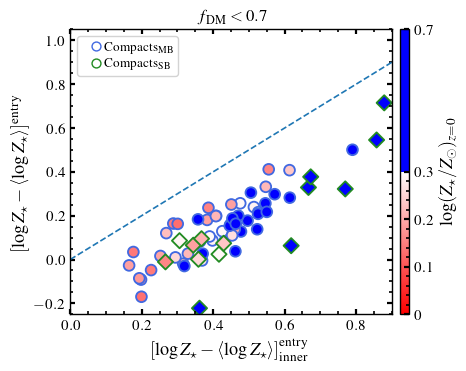

In [ ]:
plot.PlotScatter(['MBC', 'SBC'], ['SatelliteDMpoor'], 'Relative_logInnerZ_At_Entry', 
                 ['Relative_logZ_At_Entry'],  Type='z0', snap=[99], COLORBAR = ['logStarZ_99_75dex'],
title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False, 
               legend=True,LegendNames=[[ 'MBCColorbarBlackLineScatter', 'SBCColorbarBlackLineScatter']], TRANSPARENT = False,  
               cmap = 'RdGy', ratioColorbar = 30,
               alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
               fontlabel=11,
               m='o', msizet=5, quantile=0.95,framealpha = 0.85, q = 0.95,
               ylimmin = [-0.25], ylimmax = [1.05],xlimmin = [0.0], xlimmax = [0.9],
               MarkerSizes = None,
               lNum = 3.7, cNum = 5,
               legpositions = [[0, 0]],
               columnspacing = 0.5, handletextpad = -0.4, labelspacing = 0.3, loc = ['upper left'],
               savepath='PaperII/PlotScatter',  savefigname='ZEntry', dfName='PaperII', SampleName='Samples',
               bins=10, seed=16010504, mult = 4.1)

# Fig. A1


 Type:  Satellite


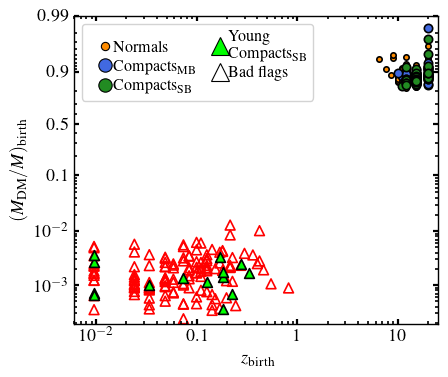

In [ ]:
plot.PlotScatter(['Normal','MBC', 'SBC',  'BadFlag', 'SBCBornYoung'], ['Satellite'], 'z_Birth', 'DMFrac_Birth',  Type='z0', snap=[99],
 title=False, medianBins=False, medianAll=False, xlabelintext=False, All=None,
                legend=True, LegendNames=[['NormalBlackLineScatter', 'MBCBlackLineScatter', 'SBCBlackLineScatter', 'SBCBornYoungBlackLineScatter', 'BadFlagBlackLineScatter']],  TRANSPARENT = False, COLORBAR = None, medianDot = False,  xscale = 'symlog',
                alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
                fontlabel=13.2,  
                m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
                MarkerSizes = None, GridMake = False,
                lNum = 3.7, cNum = 5, 
                
                ylimmin = [1.9e-4], ylimmax = [0.99], xlimmin = [-0.005], xlimmax = [25],  
                legpositions = [[0, 0]],
                columnspacing = 0.5, handletextpad = -0.2, labelspacing = 0.3, loc = ['upper left'],
                savepath='PaperII/PlotScatter',  savefigname='BADFlag', dfName='PaperII', SampleName='Samples', cmap = 'inferno',
                bins=10, seed=16010504, mult = 4.1)


# Fig. A2

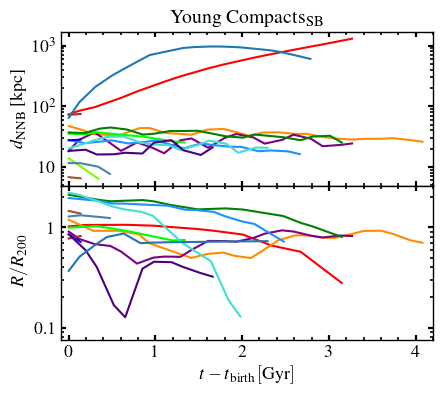

In [ ]:
SBCYoungIDs = np.array([  327, 117361, 167459, 167466, 167504, 242823, 242824, 242825, 264957, 355743, 355744, 371132, 413377, 923816])
plot.PlotID(['SBCBornYoung'],  ['rToRNearYoung', 'r_over_R_Crit200'], [SBCYoungIDs], 
            Type = 'Evolution', Xparam = ['tsincebirth', 'tsincebirth']  ,
            savepath='PaperII/PlotID',  savefigname='Young', dfName='PaperII', SampleName='SubfindID_99',  LookBackTime = True,
            #ylimmin = [-0.62, -11.2, 0.1], ylimmax = [0.5, -7.8, 2.15], xlimmin = None, xlimmax = None,
            lNum = 2, cNum = 4.8, GridMake = False,
            ColumnPlot=False, limaxis=False, xlabelintext=False, TRANSPARENT = True, legend=False, title=['Young Compacts$_\mathrm{SB}$'], lineparams=False, 
            loc='best', QuantileError = False, linewidth = 1.5, fontlabel=13,  
            Softening = True, sSFRMedian = False)

# Fig. B1


[13.802819 13.666329 13.462742 13.327794 13.126561 12.993212 12.794419
 12.662724 12.466454 12.336469 12.142804 11.950741 11.823602 11.634269
 11.508976 11.32245  11.137642 11.015405 10.833517 10.653412 10.534345
 10.298646 10.182027 10.008651  9.837158  9.723884  9.555567  9.389178
  9.224732  9.062243  8.901722  8.743182  8.586632  8.432081  8.279538
  8.079279  7.93144   7.785623  7.641832  7.45326   7.314194  7.131918
  6.997566  6.821561  6.691897  6.522119  6.355871  6.193132  6.073364
  5.878068  5.725682  5.576682  5.43103   5.288689  5.115354  4.980306
  4.815949  4.656455  4.501729  4.292939  4.206193  4.037511  3.901735
  3.744403  3.593009  3.447374  3.284507  3.128954  2.980437  2.838681
  2.684607  2.538618  2.383569  2.237743  2.145398  1.944184  1.811915
  1.688509  1.540402  1.466045  1.365945  1.28166   1.177255  1.11239
  1.036282  0.965356  0.931726  0.843642  0.763859  0.732013  0.686709
  0.639645  0.595801  0.54713   0.516909  0.474674  0.417697  0.370175
  0.270

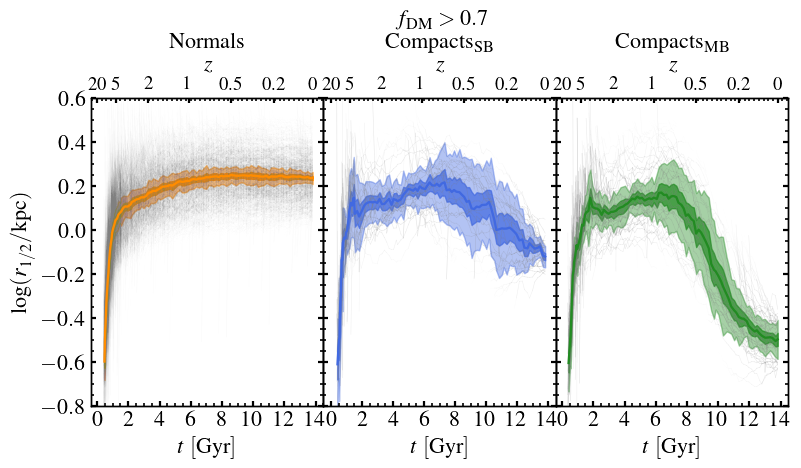

In [ ]:
plot.PlotIDsAllTogether(['NormalSatelliteDMrich','MBCSatelliteDMrich', 'SBCSatelliteDMrich'],['SubhaloHalfmassRadType4'],ylimmin = [-0.8], ylimmax = [0.6], title = ['Normals', '$f_\mathrm{DM} > 0.7$ \n Compacts$_\mathrm{SB}$', 'Compacts$_\mathrm{MB}$'], MedianPlot = True,
lNum = 4, cNum = 3, ColorMaps = [plt.get_cmap('Oranges'), plt.get_cmap('Blues'), plt.get_cmap('Greens')],
alphaShade=0.3,  linewidth=1.1,  fontlabel=16,  nboots=100,  
 columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
bins=10, seed=16040105, savepath='fig/PlotIDsAllTogether', savefigname='RandomLines',
dfName='PaperII')

# Fig. C1


 Type:  SatelliteDMpoor


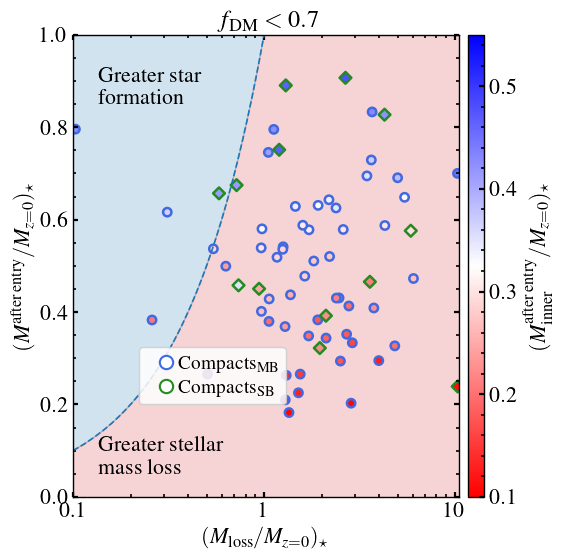

In [ ]:
plot.PlotScatter(['MBC', 'SBC'], ['SatelliteDMpoor'], 'FracStarLoss', 
                 ['FracStarAfterEntry'],  Type='z0', snap=[99], COLORBAR = ['FracStarAfterEntry_Inner'],
title=['DMpoor'], medianBins=False, medianAll=False, xlabelintext=False, All=None, GridMake = False, 
               legend=True,LegendNames=[[ 'MBCEmptyScatter', 'SBCEmptyScatter']], TRANSPARENT = False,  
               cmap = 'bwr_r',
               alphaScater=1.,   alphaShade=0.3,  linewidth=1.2, 
               fontlabel=16,
               m='o', msizet=4.5, quantile=0.95,framealpha = 0.85, q = 0.95,
               ylimmin = [0.], ylimmax = [1.],xlimmin = [0.1], xlimmax = [10.5],
               MarkerSizes = None,
               lNum = 6, cNum = 6,
               legpositions = [[0, 0]],
               columnspacing = 0.5, handletextpad = -0.4, labelspacing = 0.3, loc = [(0.17, 0.2)],
               savepath='PaperII/PlotScatter',  savefigname='FracLoss', dfName='PaperII', SampleName='Samples',
               bins=10, seed=16010504, mult = 4.1)

# Fig. E1

In [ ]:
IDs = np.array([63990, 64002, 96853, 117357, 229992, 294887, 294895])
IDsName = [str(i) for i in IDs]

plot.PlotIDsColumns(IDs, [['MDM_Norm_Max'], ['SubhaloHalfmassRadType4'], 
                    ['StarMass_In_Rhpkpc', 'StarMass_Above_Rhpkpc'],
                         
['GasMass_In_Rhpkpc', 'GasMass_Above_Rhpkpc'], ['sSFR_In_Rhpkpc', 'sSFR_Above_Rhpkpc'], ['logStar_GFM_Metallicity_In_Rhpkpc', 'logStar_GFM_Metallicity_Above_Rhpkpc'], ['Group_M_Crit200'], ['r_over_R_Crit200', 'r_over_R_Crit200_FirstGroup']], dataMarker=None, dataLine=None,  
                  title=IDsName, xlabelintext=False, lineparams=False,  QuantileError=True, 
           alphaShade=0.3,  linewidth=1.1, fontlabel=22,  nboots=100,  ColumnPlot=False, limaxis=False, 
           columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3,  Pericenter = False, postext = ['best'],
           lNum = 4, cNum = 2, PhasingPlot = False,
           NoGas = False, InfallTime = True, GridMake = False,
           ylimmin = [ 0.008, -0.54, 6.5, 7.2, -11.4, -1.5, 7.9, 0.05], ylimmax = [ 1, 1.1, 10.1, 10.2, -7.8, -0.9, 14.5, 25],
           SmallerScale = True, ShowPop = True, ShowPopName = 'SBCSatelliteDMpoor',
           Type='Evolution', Xparam='Time', savepath='PaperII/PlotIDColumns', savefigname='test', dfName='PaperII', SampleName='Samples', SatelliteTime = True,
             legend=True, LegendNames='None',  loc='best', LookBackTime = True,
           bins=10, seed=16010504, TRANSPARENT = False, Softening = False, MaxSizeType = False)

## 3. Optional diagnostics

Use these cells only if you want to record the environment used to run the notebook.


In [ ]:
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue May 12 12:21:07 2026

@author: abhner
"""

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon May 11 14:38:01 2026

@author: abhner
"""

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue May  5 15:42:13 2026

@author: abhner
"""

import matplotlib.patheffects as pe
fig = plt.figure()
plt.rcParams.update({'figure.figsize': (5, 5)})
gs = fig.add_gridspec(2, 1, hspace=0, wspace=0)
axs = gs.subplots(sharex='col', sharey='row')

Zsun =  0.0127 
SBCSatellite = TNG.extractPopulation('SBCSatellite', dfName = 'PaperII')
MBCSatellite = TNG.extractPopulation('MBCSatellite',  dfName = 'PaperII')
NormalSatellite = TNG.extractPopulation('NormalSatellite',  dfName = 'PaperII')

XSBCMax = np.array([v for v in SBCSatellite.MaxStellarMassInRad[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])
YSBC = np.log10( np.array([v for v in SBCSatellite.StarMetallicity_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])/ Zsun  ) - 0.75
XSBC = np.array([v for v in SBCSatellite.logMstarRad_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])
YSBCMax = np.log10(np.array([v for v in SBCSatellite.MaxStarMetallicity[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
DMSBC = np.array([v for v in SBCSatellite.DMFrac_99[(SBCSatellite.MaxStellarMassInRad != SBCSatellite.logMstarRad_99)].values])


XMBCMax = np.array([v for v in MBCSatellite.MaxStellarMassInRad[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])
YMBC = np.log10(np.array([v for v in MBCSatellite.StarMetallicity_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
XMBC = np.array([v for v in MBCSatellite.logMstarRad_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])
YMBCMax = np.log10(np.array([v for v in MBCSatellite.MaxStarMetallicity[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
DMMBC = np.array([v for v in MBCSatellite.DMFrac_99[(MBCSatellite.MaxStellarMassInRad != MBCSatellite.logMstarRad_99)].values])

XNormalMax = np.array([v for v in NormalSatellite.MaxStellarMassInRad[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values])
YNormal = np.log10(np.array([v for v in NormalSatellite.StarMetallicity_99[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values]) / Zsun) - 0.75
XNormal = np.array([v for v in NormalSatellite.logMstarRad_99[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values])
YNormalMax = np.log10(np.array([v for v in NormalSatellite.MaxStarMetallicity[(NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99)].values]) / Zsun) - 0.75

YNormal_50 = np.array([v for v in NormalSatellite.StarMetallicity_50.values]) - 0.75
XNormal_50 = np.array([v for v in NormalSatellite.logMstarRad_50.values])


def draw_median_arrow(ax, x0, y0, x1, y1, mask, color, edgecolor):
    if np.sum(mask) == 0:
        return

    x0m = np.median(x0[mask])
    y0m = np.median(y0[mask])
    x1m = np.median(x1[mask])
    y1m = np.median(y1[mask])

    
    prop = dict(
        arrowstyle="-|>,head_width=0.35,head_length=0.55",
        facecolor=color,
        edgecolor=color,
        lw=1.2,
        shrinkA=0,
        shrinkB=0,
        alpha=1.0,
        mutation_scale=16,
    )
    
    ann = ax.annotate(
        "",
        xy=(x1m, y1m),
        xytext=(x0m, y0m),
        arrowprops=prop,
        zorder=30,
    )
    
    ann.arrow_patch.set_path_effects([
        pe.Stroke(linewidth=4.2, foreground=edgecolor),
        pe.Normal()
    ])
    ann.arrow_patch.set_zorder(30)
    
def draw_median_arrow_smaller(ax, x0, y0, x1, y1, mask, color, edgecolor):
    if np.sum(mask) == 0:
        return

    x0m = np.median(x0[mask])
    y0m = np.median(y0[mask])
    x1m = np.median(x1[mask])
    y1m = np.median(y1[mask])

    
    prop = dict(
        arrowstyle="-|>,head_width=0.15,head_length=0.25",
        facecolor=color,
        edgecolor=color,
        lw=1.8,
        shrinkA=0,
        shrinkB=0,
        alpha=1.0,
        mutation_scale=16,
    )
    
    ann = ax.annotate(
        "",
        xy=(x1m, y1m),
        xytext=(x0m, y0m),
        arrowprops=prop,
        zorder=30,
    )
    
    ann.arrow_patch.set_path_effects([
        pe.Stroke(linewidth=4.2, foreground=edgecolor),
        pe.Normal()
    ])
    ann.arrow_patch.set_zorder(30)

poor_sbc = DMSBC < 0.7
rich_sbc = DMSBC > 0.7
poor_mbc = DMMBC < 0.7
rich_mbc = DMMBC > 0.7

# ---------------------------
# Robust median tracks for Normals
# replace the current "Define bins for x" + "HIGHER REDSHIFT" blocks by this
# ---------------------------

def get_binned_median_track(x, y, bins, min_count=5, qlo=25, qhi=75):
    x = np.asarray(x)
    y = np.asarray(y)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    idx = np.digitize(x, bins) - 1

    x_track = []
    y_med = []
    y_lo  = []
    y_hi  = []

    for i in range(len(bins) - 1):
        m = idx == i
        if np.sum(m) < min_count:
            continue

        xb = x[m]
        yb = y[m]

        x_track.append(np.median(xb))          # more robust than fixed bin center
        y_med.append(np.median(yb))
        y_lo.append(np.percentile(yb, qlo))
        y_hi.append(np.percentile(yb, qhi))

    return np.array(x_track), np.array(y_med), np.array(y_lo), np.array(y_hi)


# robust masks
mask_norm_99 = (
    (NormalSatellite.MaxStellarMassInRad != NormalSatellite.logMstarRad_99).values &
    np.isfinite(NormalSatellite.logMstarRad_99.values) &
    np.isfinite(NormalSatellite.StarMetallicity_99.values) &
    (NormalSatellite.StarMetallicity_99.values > 0)
)

mask_norm_50 = (
    np.isfinite(NormalSatellite.logMstarRad_50.values) &
    np.isfinite(NormalSatellite.StarMetallicity_50.values) 
)

# redefine Normal tracks consistently
XNormal = NormalSatellite.logMstarRad_99.values[mask_norm_99]
YNormal = np.log10(NormalSatellite.StarMetallicity_99.values[mask_norm_99] / Zsun) - 0.75

XNormal_50 = NormalSatellite.logMstarRad_50.values
YNormal_50 = NormalSatellite.StarMetallicity_50.values - 0.75

# same bins for z=0 and z~1
num_bins = 20
xmin = np.nanmin(np.concatenate([XNormal, XNormal_50]))
xmax = np.nanmax(np.concatenate([XNormal, XNormal_50]))
bins = np.linspace(8.3, 10.1, num_bins + 1)

xmed_0, ymed_0, ylo_0, yhi_0 = get_binned_median_track(
    XNormal, YNormal, bins, min_count=5, qlo=25, qhi=75
)

xmed_50, ymed_50, ylo_50, yhi_50 = get_binned_median_track(
    XNormal_50, YNormal_50, bins, min_count=5, qlo=25, qhi=75
)

# z = 0
axs[1].plot(xmed_0, ymed_0, color='darkorange', lw=1.4, label='Normal population at $z=0$')
axs[1].fill_between(xmed_0, ylo_0, yhi_0, color='tab:orange', alpha=0.25)

axs[0].plot(xmed_0, ymed_0, color='darkorange', lw=1.4, label='Normal population at $z=0$')
axs[0].fill_between(xmed_0, ylo_0, yhi_0, color='tab:orange', alpha=0.25)

# z ~ 1 (Max)
axs[1].plot(xmed_50, ymed_50, color='darkorange', ls='--', lw=1.4, label='Normal population at $z\\sim1$')
axs[0].plot(xmed_50, ymed_50, color='darkorange', ls='--', lw=1.4, label='Normal population at $z\\sim1$')

# optional: if you also want a lighter shaded region for z~1, uncomment below
axs[1].fill_between(xmed_50, ylo_50, yhi_50, color='tab:orange', alpha=0.10)
axs[0].fill_between(xmed_50, ylo_50, yhi_50, color='tab:orange', alpha=0.10)


# MAXIMUM (smaller / lighter markers)
axs[1].scatter(XSBCMax[poor_sbc],
            YSBCMax[poor_sbc],
            color='peru',
            edgecolor='k', alpha=.45,
            lw = 1.,
            marker='D',
            ls = 'solid',
            s=2.8*6.5)

axs[1].scatter(XSBCMax[rich_sbc],
            YSBCMax[rich_sbc],
            color='blueviolet',
            edgecolor='k', alpha=.45,
            lw = 1.1,
            marker='D',
            ls = 'solid',
            s=2.8*6.5)

axs[0].scatter(XMBCMax[poor_mbc],
            YMBCMax[poor_mbc],
            color='peru',
            edgecolor='k', alpha=.45,
            lw = 1.1,
            marker='o',
            ls = 'solid',
            s=2.8*6.5)

axs[0].scatter(XMBCMax[rich_mbc],
            YMBCMax[rich_mbc],
            color='blueviolet',
            edgecolor='k', alpha=.45,
            lw = 1.1,
            marker='o',
            ls = 'solid',
            s=2.8*6.5)

# z = 0 (larger / darker markers)
axs[1].scatter(XSBC[poor_sbc],
            YSBC[poor_sbc],
            color='peru',
            edgecolor='k', alpha=.75,
            lw = 0.9,
            marker='D',
            s=6*6.5)

axs[1].scatter(XSBC[rich_sbc],
            YSBC[rich_sbc],
            color='blueviolet',
            edgecolor='k', alpha=.75,
            lw = 0.9,
            marker='D',
            s=6*6.5)

axs[0].scatter(XMBC[poor_mbc],
            YMBC[poor_mbc],
            color='peru',
            edgecolor='k', alpha=.75,
            lw = 0.9,
            marker='o',
            s=6*6.5)

axs[0].scatter(XMBC[rich_mbc],
            YMBC[rich_mbc],
            color='blueviolet',
            edgecolor='k', alpha=.75,
            lw = 0.9,
            marker='o',
            s=6*6.5)



# median arrows
# SB panel
if np.sum(poor_sbc) > 0:
    draw_median_arrow(axs[1], XSBCMax, YSBCMax, XSBC, YSBC, poor_sbc, 'peru', 'forestgreen')
# if np.sum(rich_sbc) > 0:
#     draw_median_arrow_smaller(axs[1], XSBCMax, YSBCMax, XSBC, YSBC, rich_sbc, 'blueviolet', 'forestgreen')

# MB panel
if np.sum(poor_mbc) > 0:
    draw_median_arrow(axs[0], XMBCMax, YMBCMax, XMBC, YMBC, poor_mbc, 'peru', 'royalblue')
# if np.sum(rich_mbc) > 0:
#     draw_median_arrow_smaller(axs[0], XMBCMax, YMBCMax, XMBC, YMBC, rich_mbc, 'blueviolet', 'royalblue')



legend_handles = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='blueviolet', markeredgecolor='k', markersize=6, label='$f_\mathrm{DM} > 0.7$'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='peru', markeredgecolor='k', markersize=6, label='$f_\mathrm{DM} < 0.7$'),
    Line2D([0], [0], color='darkorange', lw=0, label='Normals:'),
    Line2D([0], [0], color='darkorange', lw=1.2, ls='--', label='$z = 1$'),
    Line2D([0], [0], color='darkorange', lw=1.2, ls='-', label='$z=0$'),
]
axs[0].legend(handles=legend_handles, fontsize=8.5, loc='upper right', frameon=True)


epoch_handles = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='k', markeredgecolor='k', alpha=0.8, markersize=6, label=r'$z=0$'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='k', markeredgecolor='k', alpha=0.2,markersize=6, label=r'epoch of maximum $M_\star$'),

    # Patch(facecolor='0.35', edgecolor='k', alpha=0.8,
    #       label=r'$z=0$'),

    # Patch(facecolor='0.35', edgecolor='k', alpha=0.2,
    #       label=r'epoch of maximum $M_\star$'),
]
axs[1].legend(handles=epoch_handles, fontsize=8.0,  loc='upper right',
              frameon=True)


plt.xlabel('$\log(M_\star/\mathrm{M}_\odot)$', fontsize = 11)
axs[0].set_ylabel(r'$\log( Z_\star / Z_\odot)$', fontsize = 11)
axs[1].set_ylabel(r'$\log( Z_\star / Z_\odot)$', fontsize = 11)
axs[0].set_ylim(np.log10(0.0075 / Zsun) - 0.75, np.log10(0.055 / Zsun) - 0.75)
axs[1].set_ylim(np.log10(0.0075 / Zsun) - 0.75, np.log10(0.055 / Zsun) - 0.75)
axs[1].tick_params(labelsize=0.99*11)
axs[0].tick_params(labelsize=0.99*11)

axs[0].set_xlim(8.3, 10.1)
axs[1].set_xlim(8.3, 10.1)
axs[0].text(9.5, -0.1 - 0.75,'Compacts$_\mathrm{MB}$', fontsize = 11,   color = 'royalblue')
axs[1].text(9.5, -0.1 - 0.75, 'Compacts$_\mathrm{SB}$', fontsize = 11,   color ='forestgreen')

plt.savefig(os.getenv('HOME')+'/TNG_Analyzes/Figs/TNG50/PaperII/PlotScatter/Zmetallicty.pdf', bbox_inches='tight',)


In [ ]:
plot.PlotMedianEvolution(['Normal','SBC', 'MBC'], ['SatelliteDMrich'], ['log_sSFR__fixed_0p5pkpc', 'sSFR_Ratio_05_2p5_pkpc'], 
                     Type='Evolution', Xparam=['Time'], title=['DMrich'], 
                        xlabelintext=False, lineparams=False,  LookBackTime = True, 
                        ColumnPlot=True, limaxis=True,  legend=True,  legendColumn = True, 
                        Transparent = True, Text = None, Pericenter = False, Supertitle = False, GridMake = False,
                        savepath='PaperII/PlotMedianEvolution',  savefigname='Size_Test', dfName='PaperII', SampleName='SubfindID_99', 
                        Supertitle_Name = 'DM-rich',LegendNames=[['Normal', 'MBC', 'SBC'], ['SatelliteDMrichCO', 'CentralCO']],
                        loc = ['best'],  loctext = ['best'], EntryMedian = True,
                        ylimmin = [-10.7, 0.7], ylimmax = [-8.6, 1.8],
                        legpositions = [[0, 0]], 
                        lNum = 2.3, cNum = 5,
                        alphaShade=0.3,  linewidth=1.1, framealpha = 0.95,  fontlabel=12,   nboots=100,  
                        Supertitle_y = 0.99, Softening = True, columnspacing = 0.5, handletextpad = 0.4, labelspacing = 0.3, 
                        bins=10, seed=16040105)